In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [3]:
df3com = pd.read_csv("dataset_3comp_for_graph.csv")
print(df3com.columns)
df4com = pd.read_csv("dataset_4comp_for_graph.csv")
print(df4com.columns)

Index(['source', 'TIME', 'suma_psa', 'avg_sp', 'avg_ox'], dtype='object')
Index(['source', 'TIME', 'suma_psa', 'avg_sp', 'avg_ox'], dtype='object')


In [4]:
sub_dfs_comp3 = {source_name: group for source_name, group in df3com.groupby('source')}
sub_dfs_comp4 = {source_name: group for source_name, group in df4com.groupby('source')}

print(sub_dfs_comp3.keys())
print(sub_dfs_comp4.keys())

dict_keys(['POX37', 'POX38', 'POX40', 'POX42', 'POX46', 'POX48', 'POX50', 'POX51', 'POX55', 'POX59', 'POX60', 'POX61', 'POX63', 'POX65'])
dict_keys(['POX10', 'POX11', 'POX13', 'POX15', 'POX16', 'POX17', 'POX18', 'POX19', 'POX20', 'POX21', 'POX22', 'POX23', 'POX24', 'POX25', 'POX26', 'POX27', 'POX28', 'POX29', 'POX3', 'POX30', 'POX31', 'POX32', 'POX33', 'POX34', 'POX35', 'POX39', 'POX41', 'POX43', 'POX44', 'POX45', 'POX49', 'POX53', 'POX54', 'POX56', 'POX57', 'POX58', 'POX6', 'POX62', 'POX8', 'POX9', 'POXC1'])


In [5]:
def graph(df, title=None, sp=None, var="avg_ox", ammount=None, var_name="Prom. de oxigeno medido"):

    if ammount:
        df = df.head(ammount)


    ## 2. Algoritmo: Detectar cambios de estado
    #df['periodo'] = (df['suma_psa'] != df['suma_psa'].shift()).cumsum()
    #bloques_activos = df[df['suma_psa'] > 0].groupby('periodo')


    #======================================================================================

    colores_estados = {
        1: "blue",
        2: "green",
        3: "yellow",
        4: "orange",
        5: "red",
        6: "purple"
    }

    # 2. Algoritmo: Detectar cambios de estado
    df['grupo'] = (df['suma_psa'] != df['suma_psa'].shift()).cumsum()

    # CAMBIO AQUÍ: Filtramos cualquier cosa que NO sea cero
    bloques_activos = df[df['suma_psa'] != 0].groupby('grupo')

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(df["TIME"], df[var], color="black", linewidth=1.5, label=var_name)

    ax.plot(df["TIME"], df["avg_sp"], color="red", linewidth=1.5, label="avg_sp")


    # Un conjunto (set) para controlar qué etiquetas ya pusimos en la leyenda
    leyendas_registradas = set()

    for _, grupo in bloques_activos:
        inicio = grupo['TIME'].min()
        fin = grupo['TIME'].max()
        
        # Obtenemos el número de estado de este bloque específico
        id_estado = grupo['suma_psa'].iloc[0]
        
        # Buscamos su color en el diccionario (si no existe, usa gris por defecto)
        color_bloque = colores_estados.get(id_estado, "black")
        label_bloque = f"PSA encendidos: {int(id_estado)}"
        
        # Evitamos que la leyenda se duplique si el mismo estado aparece varias veces
        if label_bloque not in leyendas_registradas:
            ax.axvspan(inicio, fin, color=color_bloque, alpha=0.5, label=label_bloque)
            leyendas_registradas.add(label_bloque)
        else:
            ax.axvspan(inicio, fin, color=color_bloque, alpha=0.5)

#================================================================================================


    #fig, ax = plt.subplots(figsize=(12, 6))
    #ax.plot(df["TIME"], df[var], color="black", linewidth=1.5, label=var_name)

    #ax.plot(df["TIME"], df["avg_sp"], color="red", linewidth=1.5, label="avg_sp")

    ## Iterar automáticamente sobre cada bloque detectado para sombrearlo
    #primera_vez = True
    #for _, grupo in bloques_activos:
    #    inicio = grupo['TIME'].min()
    #    fin = grupo['TIME'].max()
        
    #    # El condicional es solo para que la leyenda no se repita por cada bloque
    #    if primera_vez:
    #        ax.axvspan(inicio, fin, color='orange', alpha=0.7, label='PSA encendido')
    #        primera_vez = False
    #    else:
    #        ax.axvspan(inicio, fin, color='orange', alpha=0.7)

    ##if sp:
    ##    ax.axhline(y=sp, color="red", linestyle="--", linewidth=2, label=f"Setpoint: {sp}")

    if title:
        ax.set_title(title, fontsize=14, fontweight='bold')
    #ax.set_xlabel("Fecha")
    ax.set_ylabel(var_name)
    ax.grid(False)
    ax.legend(loc="upper left")

    plt.tight_layout()
    plt.show()



C:\Users\felip\AppData\Local\Temp\ipykernel_24880\2587497079.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grupo'] = (df['suma_psa'] != df['suma_psa'].shift()).cumsum()


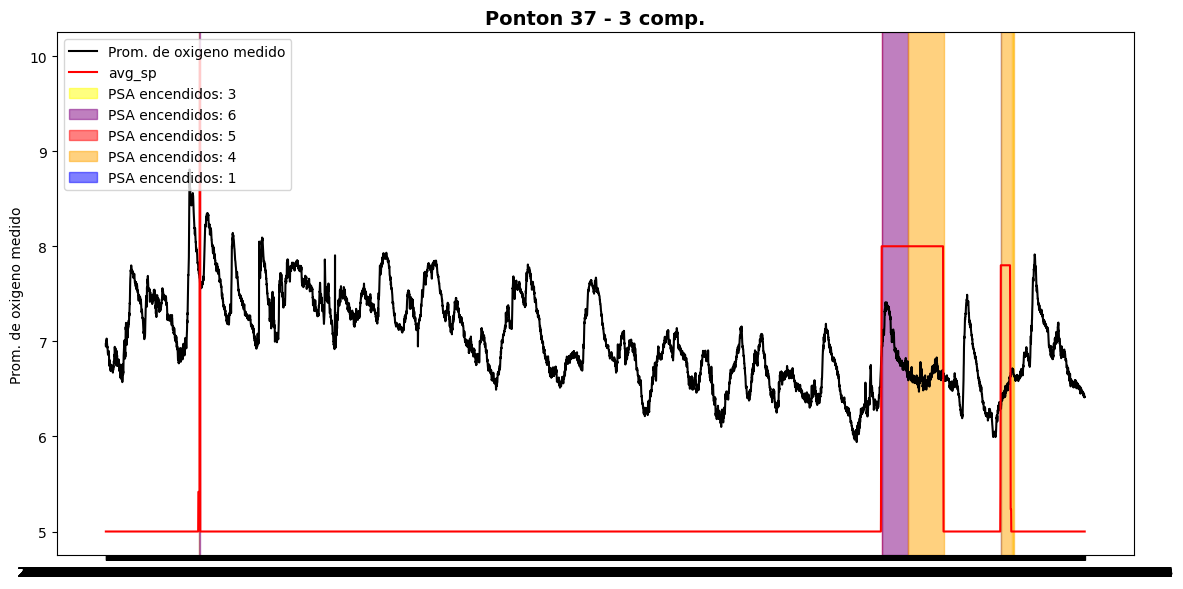

C:\Users\felip\AppData\Local\Temp\ipykernel_24880\2587497079.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grupo'] = (df['suma_psa'] != df['suma_psa'].shift()).cumsum()


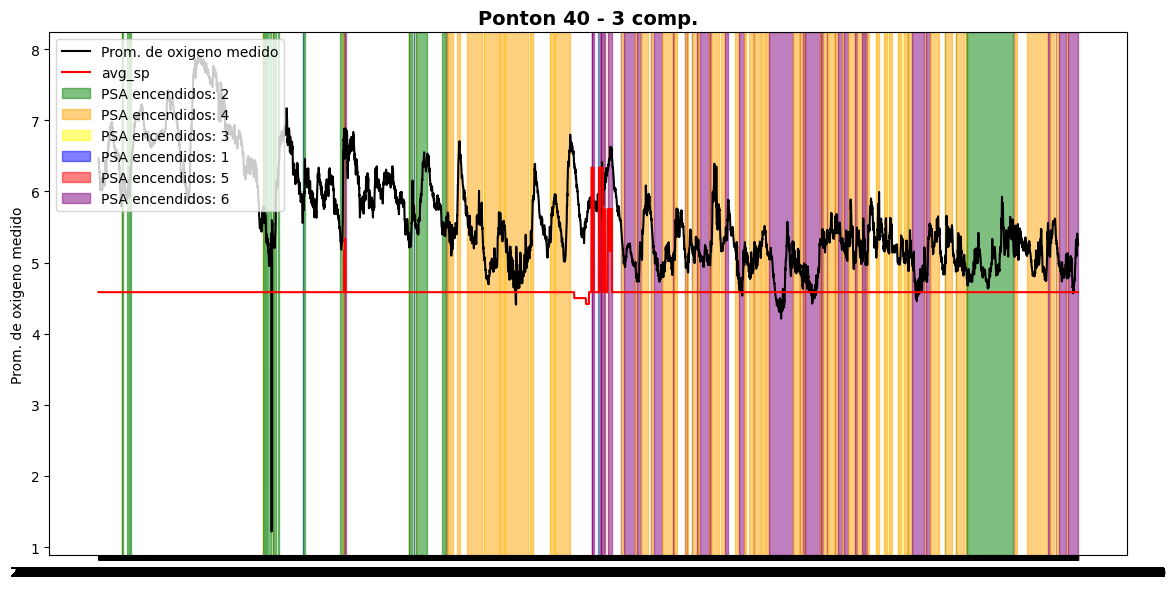

In [6]:
graph(sub_dfs_comp3["POX37"], title="Ponton 37 - 3 comp.", ammount=10000)
graph(sub_dfs_comp3["POX40"], title="Ponton 40 - 3 comp.", ammount=10000)

C:\Users\felip\AppData\Local\Temp\ipykernel_24880\2587497079.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grupo'] = (df['suma_psa'] != df['suma_psa'].shift()).cumsum()


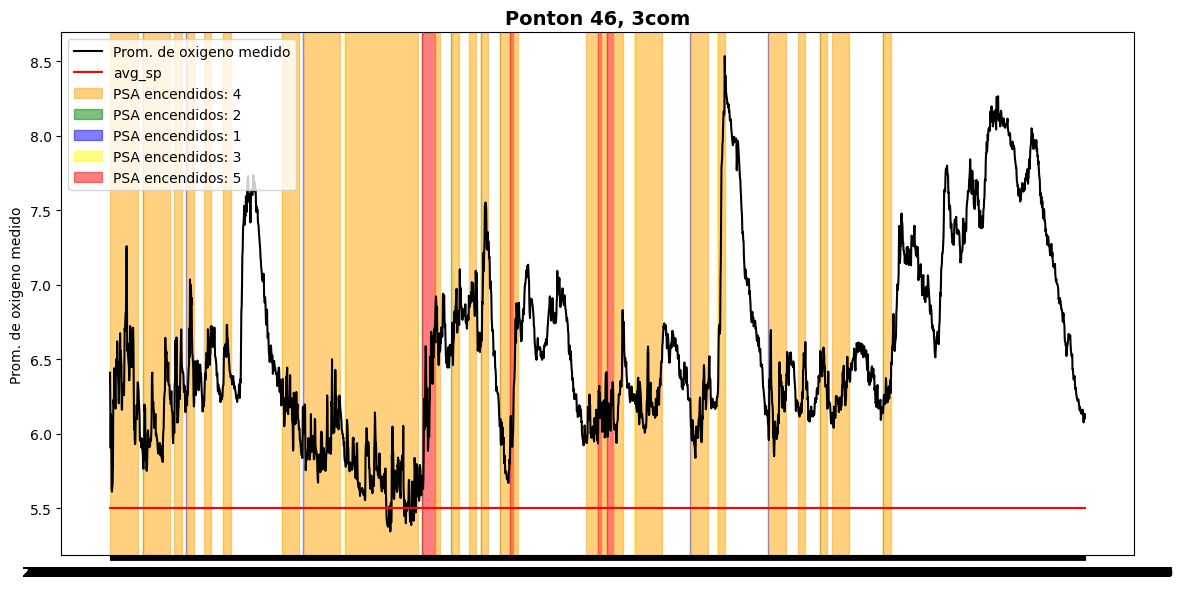

C:\Users\felip\AppData\Local\Temp\ipykernel_24880\2587497079.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grupo'] = (df['suma_psa'] != df['suma_psa'].shift()).cumsum()


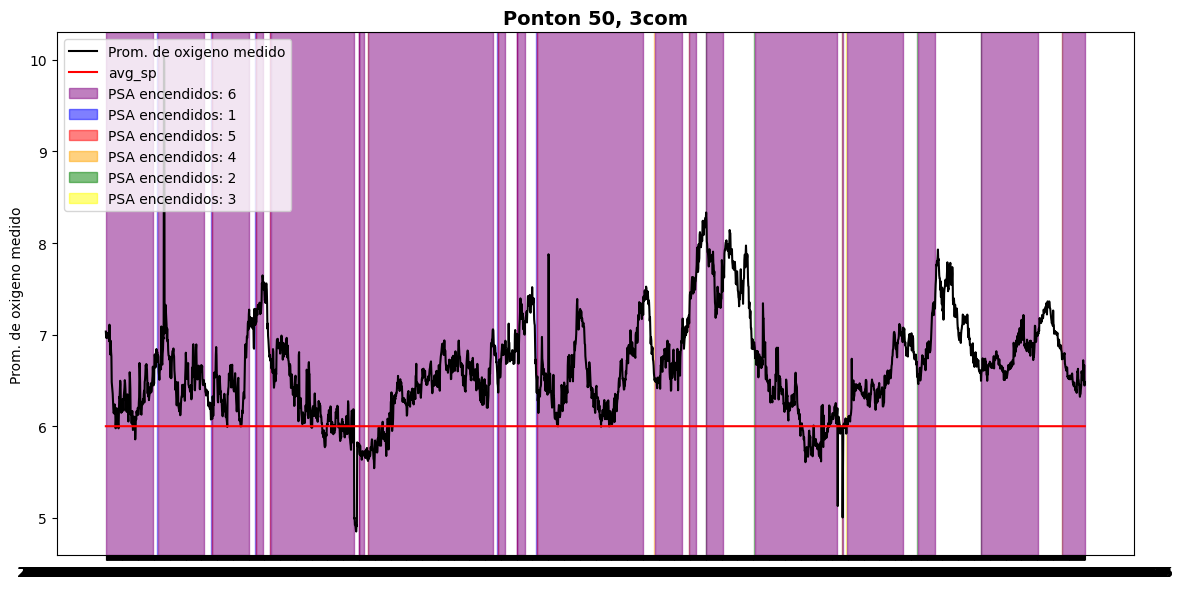

In [7]:
graph(sub_dfs_comp3["POX46"], title=f"Ponton {46}, 3com", ammount=3000)
graph(sub_dfs_comp3["POX50"], title=f"Ponton {50}, 3com", ammount=3000)

C:\Users\felip\AppData\Local\Temp\ipykernel_24880\2587497079.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grupo'] = (df['suma_psa'] != df['suma_psa'].shift()).cumsum()


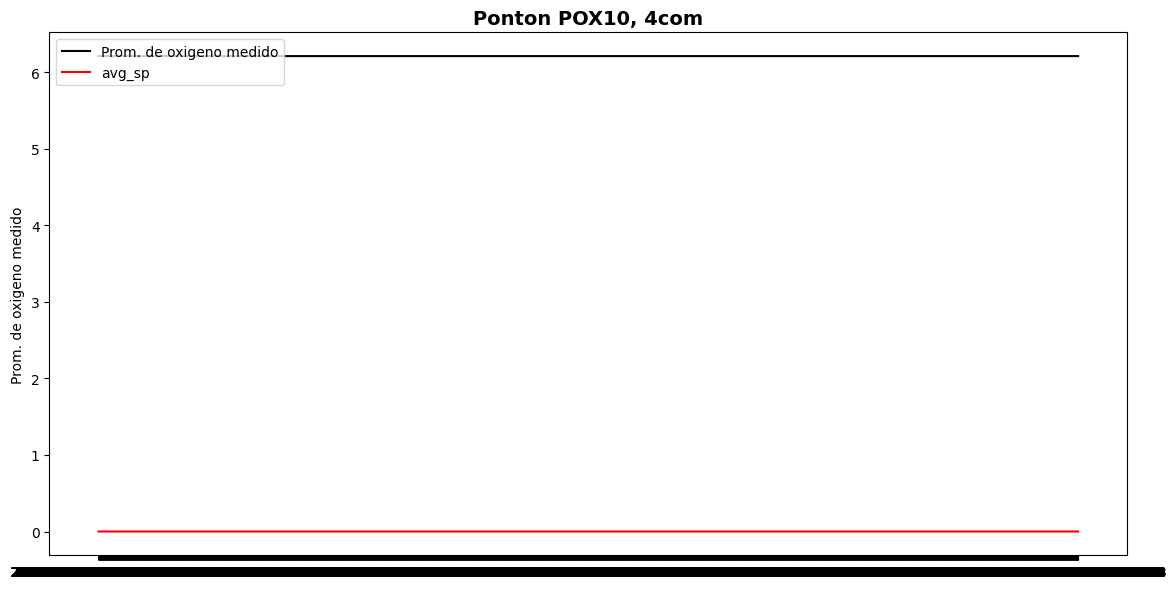

C:\Users\felip\AppData\Local\Temp\ipykernel_24880\2587497079.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grupo'] = (df['suma_psa'] != df['suma_psa'].shift()).cumsum()


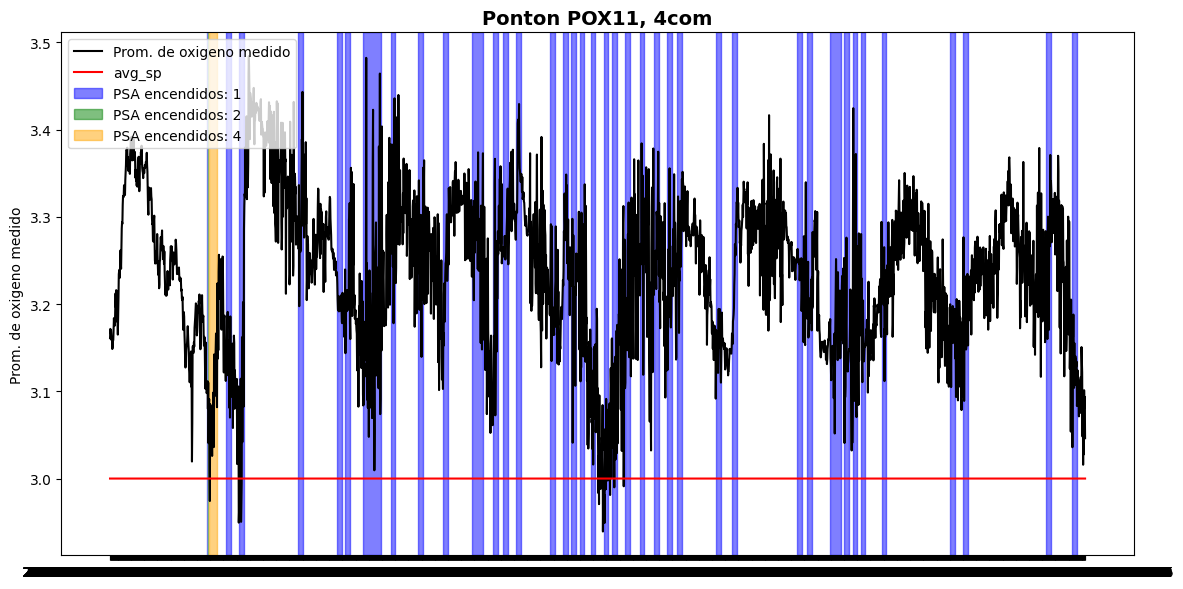

C:\Users\felip\AppData\Local\Temp\ipykernel_24880\2587497079.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grupo'] = (df['suma_psa'] != df['suma_psa'].shift()).cumsum()


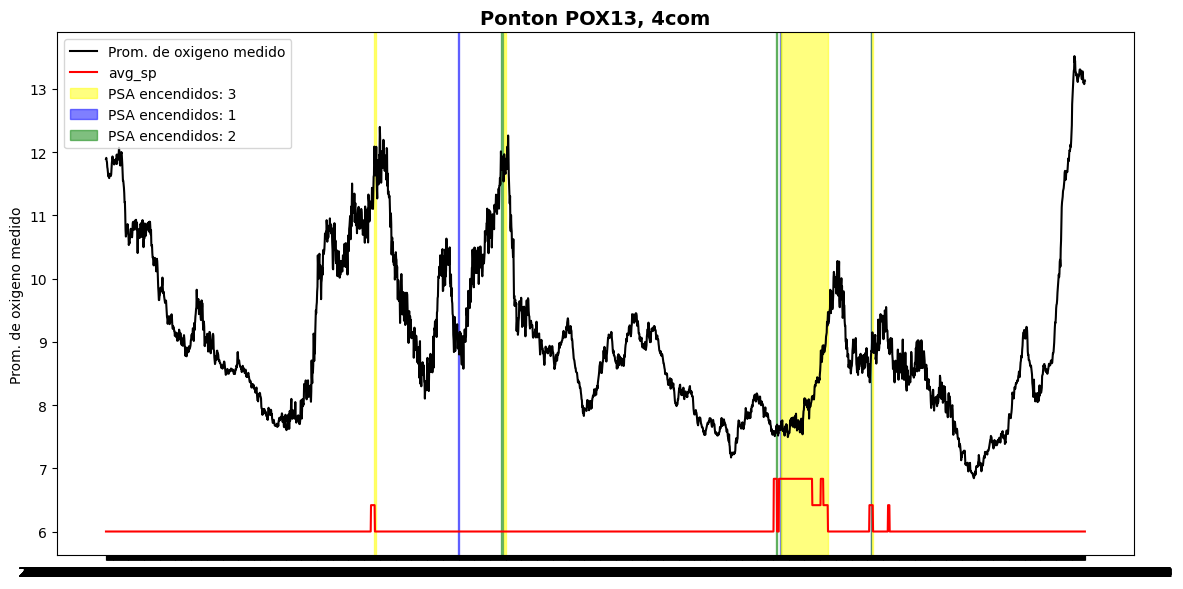

C:\Users\felip\AppData\Local\Temp\ipykernel_24880\2587497079.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grupo'] = (df['suma_psa'] != df['suma_psa'].shift()).cumsum()


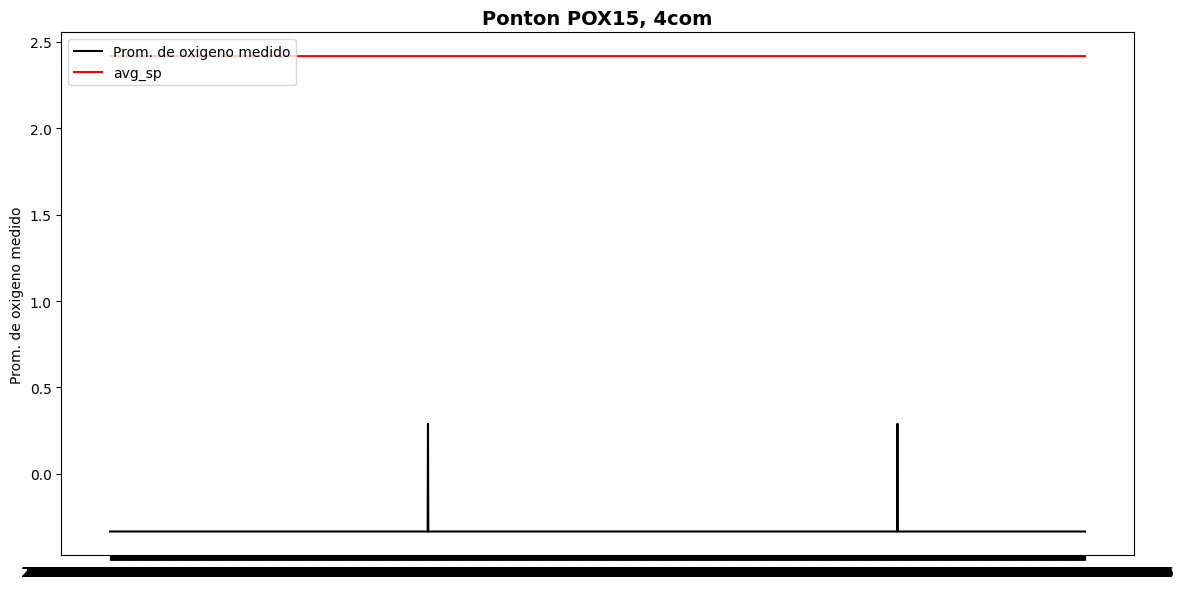

C:\Users\felip\AppData\Local\Temp\ipykernel_24880\2587497079.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grupo'] = (df['suma_psa'] != df['suma_psa'].shift()).cumsum()


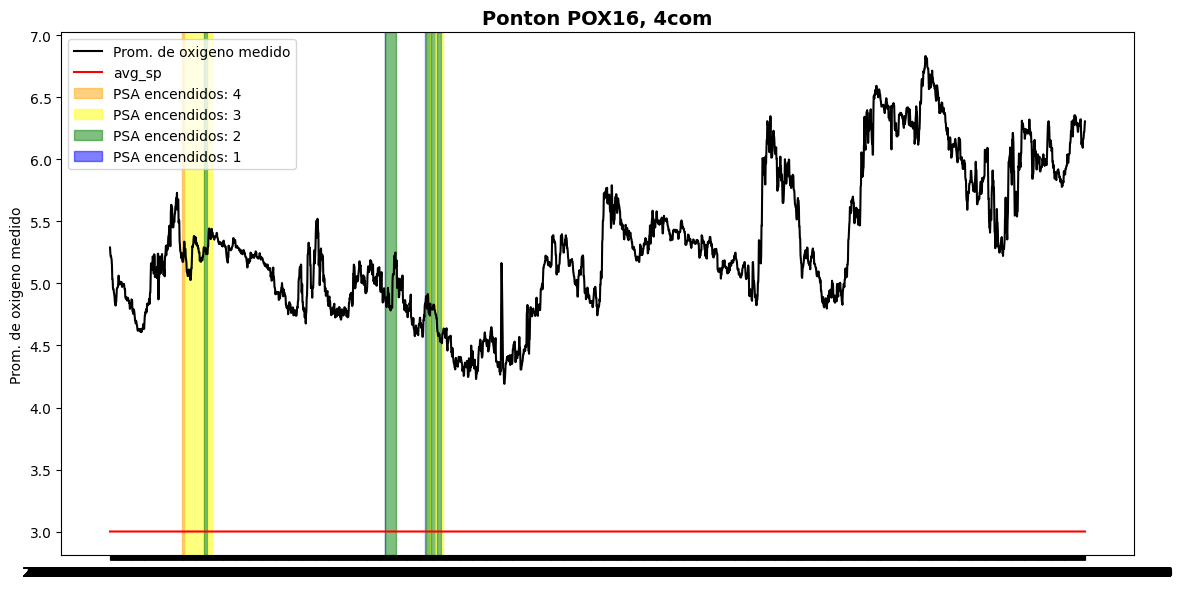

C:\Users\felip\AppData\Local\Temp\ipykernel_24880\2587497079.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grupo'] = (df['suma_psa'] != df['suma_psa'].shift()).cumsum()


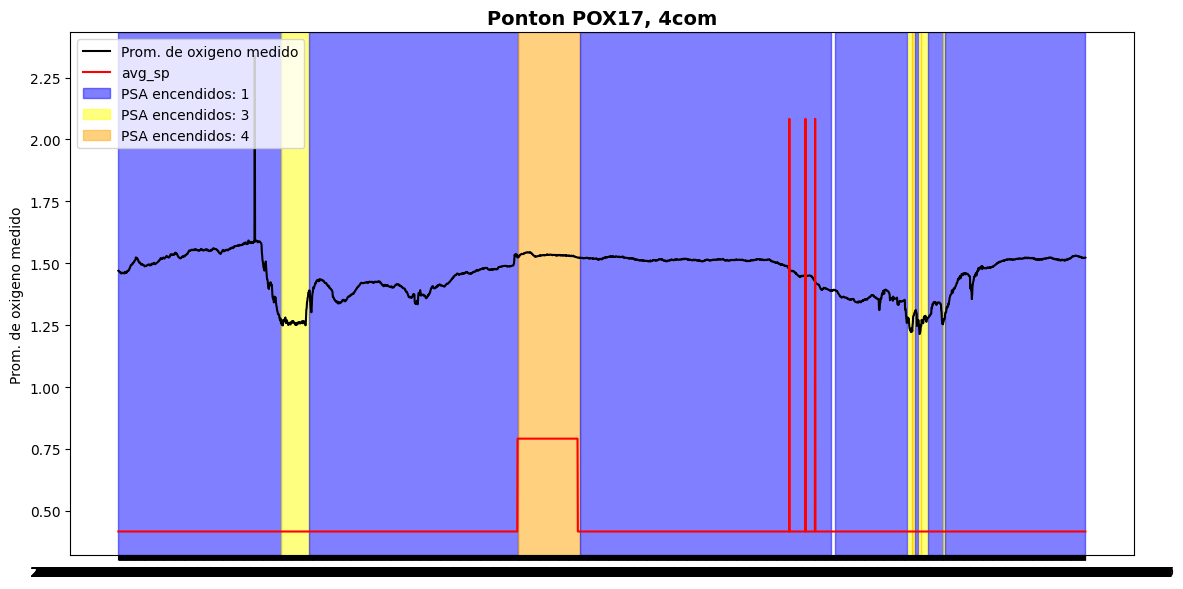

C:\Users\felip\AppData\Local\Temp\ipykernel_24880\2587497079.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grupo'] = (df['suma_psa'] != df['suma_psa'].shift()).cumsum()


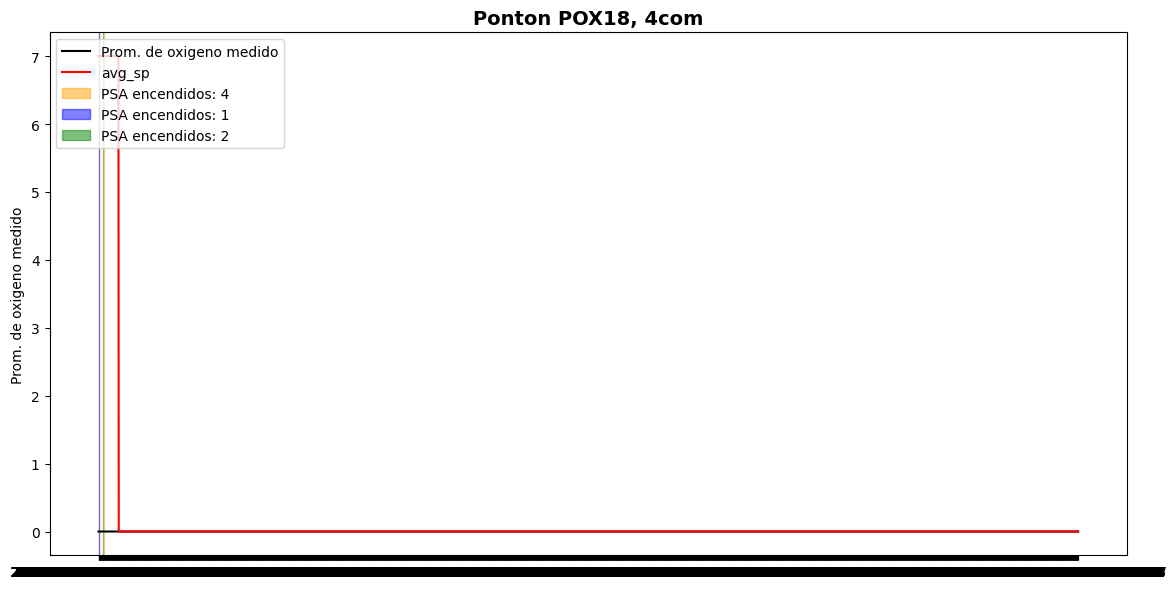

C:\Users\felip\AppData\Local\Temp\ipykernel_24880\2587497079.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grupo'] = (df['suma_psa'] != df['suma_psa'].shift()).cumsum()


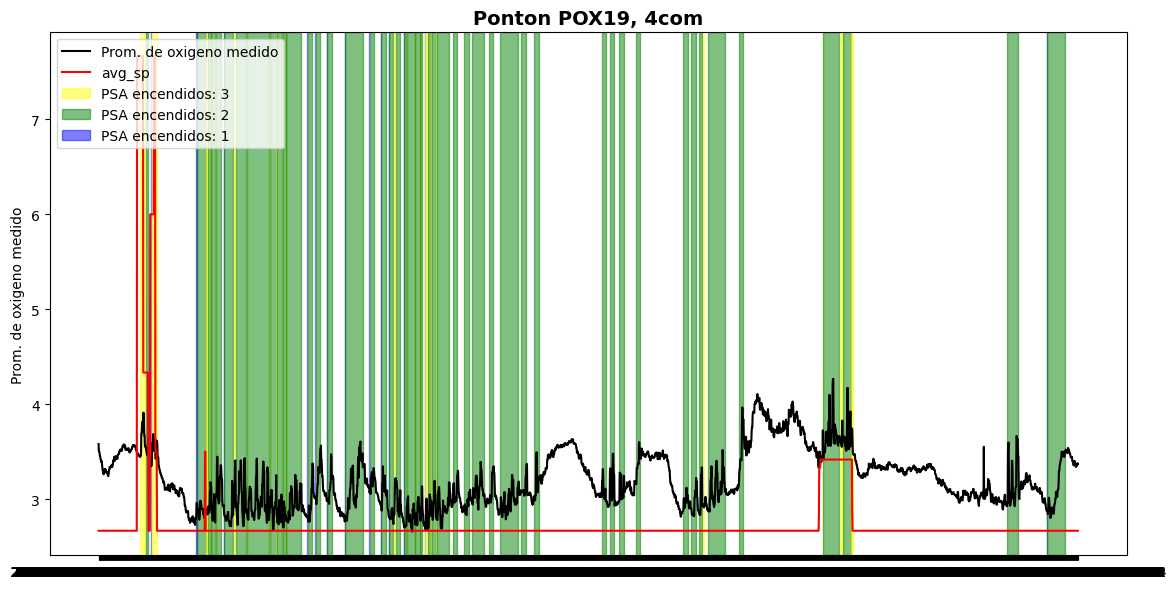

C:\Users\felip\AppData\Local\Temp\ipykernel_24880\2587497079.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grupo'] = (df['suma_psa'] != df['suma_psa'].shift()).cumsum()


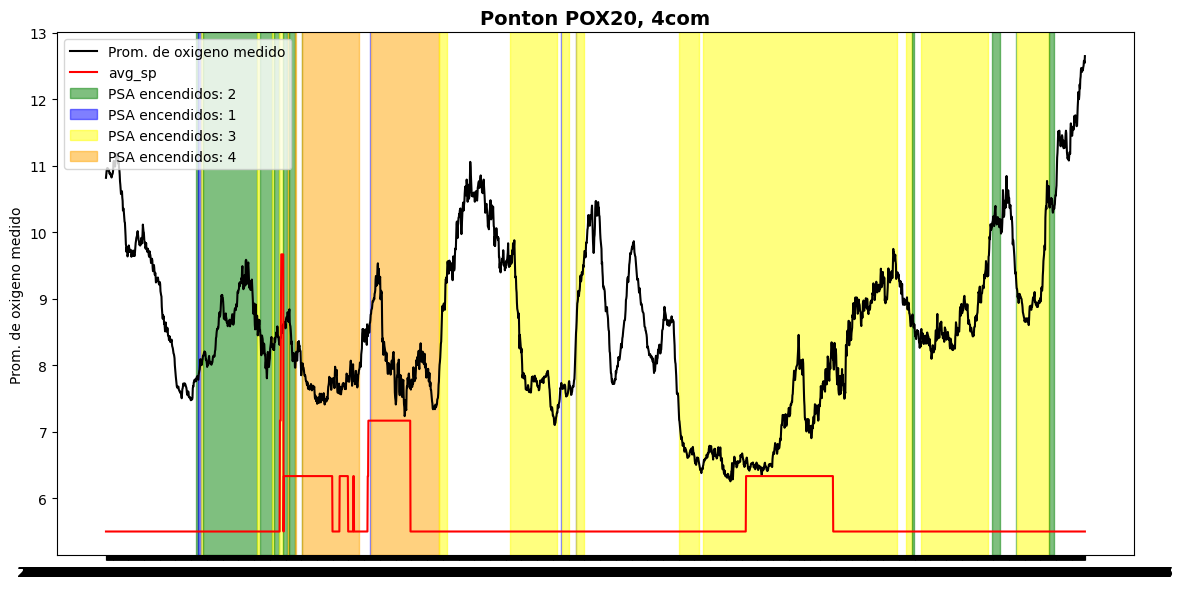

C:\Users\felip\AppData\Local\Temp\ipykernel_24880\2587497079.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grupo'] = (df['suma_psa'] != df['suma_psa'].shift()).cumsum()


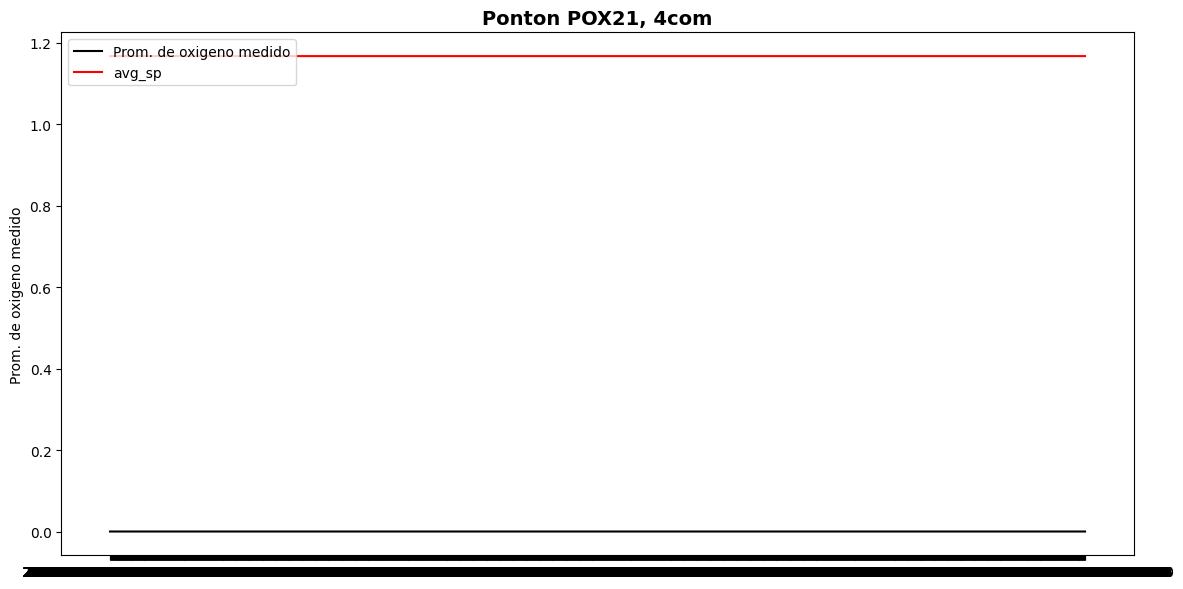

C:\Users\felip\AppData\Local\Temp\ipykernel_24880\2587497079.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grupo'] = (df['suma_psa'] != df['suma_psa'].shift()).cumsum()


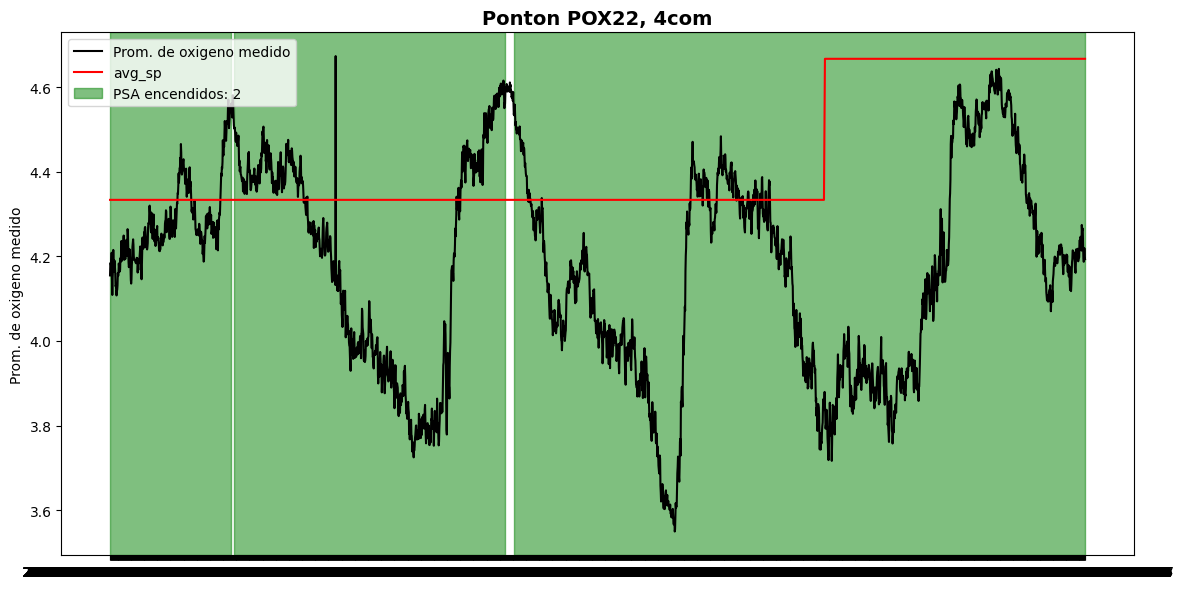

C:\Users\felip\AppData\Local\Temp\ipykernel_24880\2587497079.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grupo'] = (df['suma_psa'] != df['suma_psa'].shift()).cumsum()


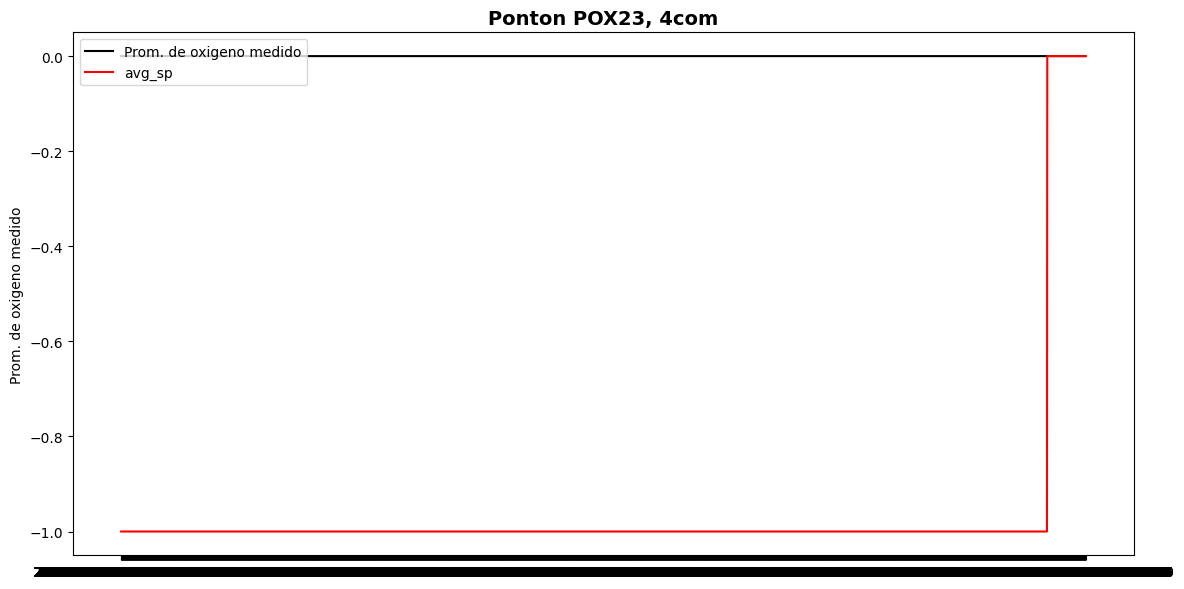

C:\Users\felip\AppData\Local\Temp\ipykernel_24880\2587497079.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grupo'] = (df['suma_psa'] != df['suma_psa'].shift()).cumsum()


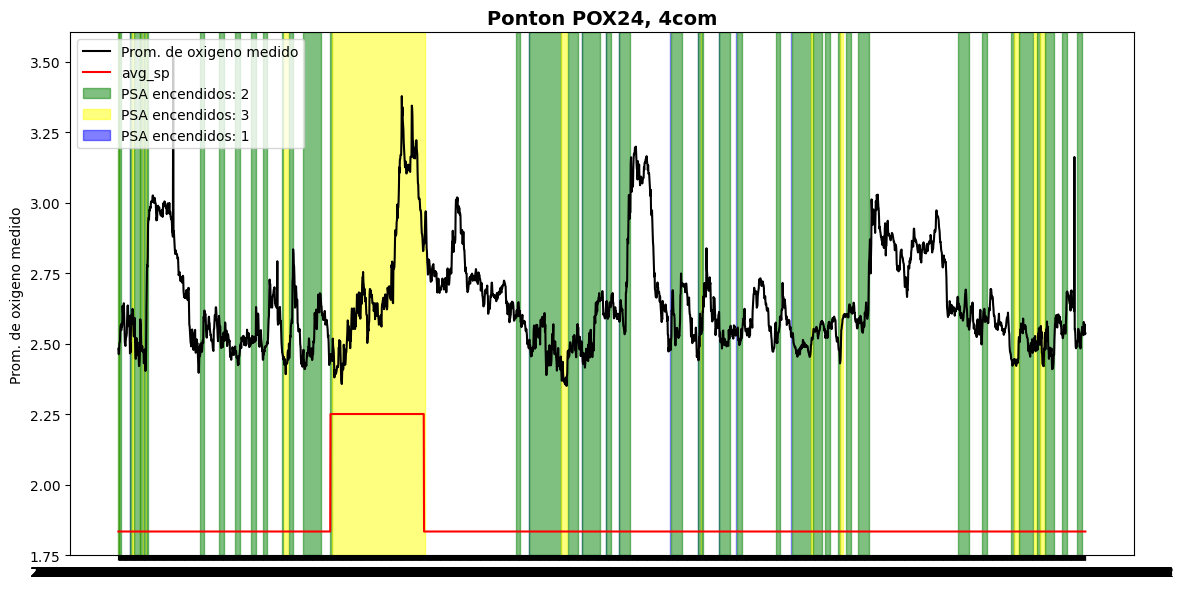

C:\Users\felip\AppData\Local\Temp\ipykernel_24880\2587497079.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grupo'] = (df['suma_psa'] != df['suma_psa'].shift()).cumsum()


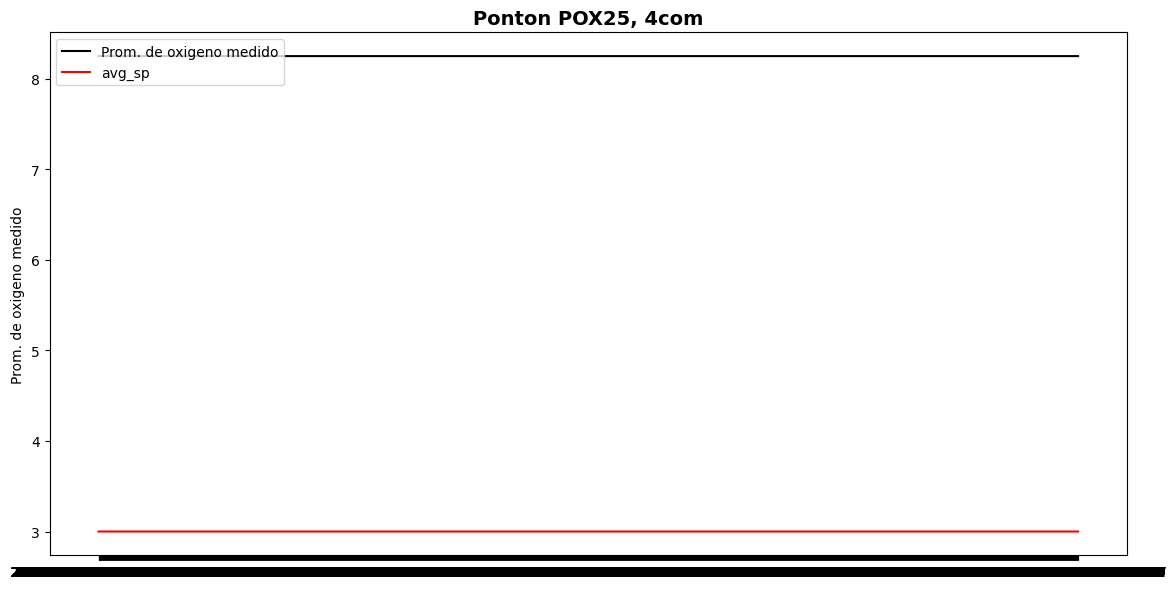

C:\Users\felip\AppData\Local\Temp\ipykernel_24880\2587497079.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grupo'] = (df['suma_psa'] != df['suma_psa'].shift()).cumsum()


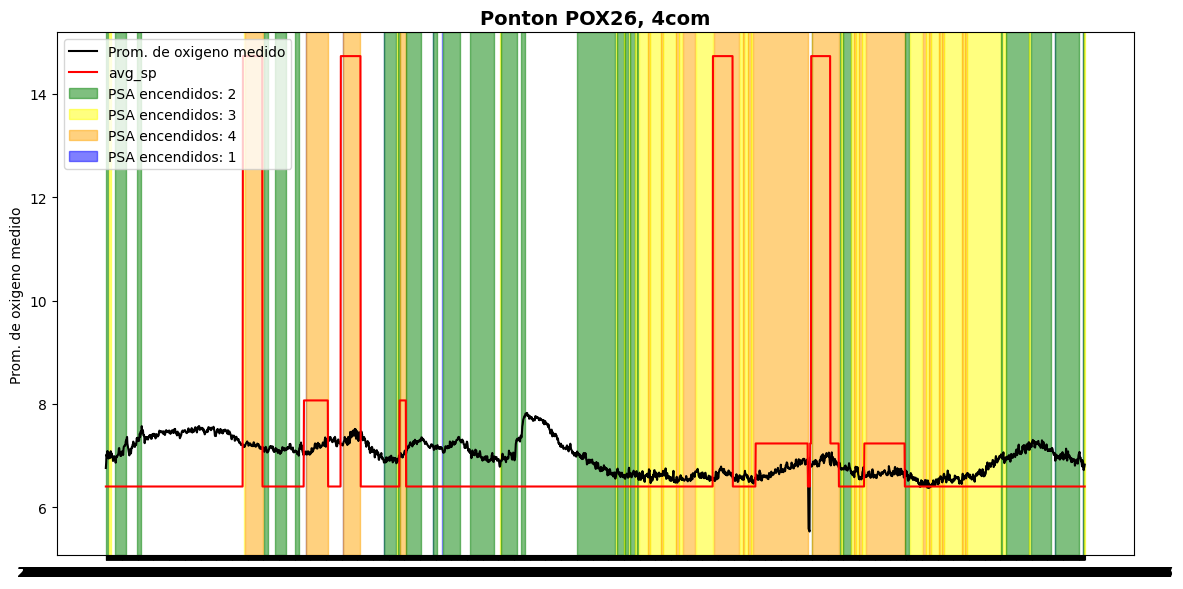

C:\Users\felip\AppData\Local\Temp\ipykernel_24880\2587497079.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grupo'] = (df['suma_psa'] != df['suma_psa'].shift()).cumsum()


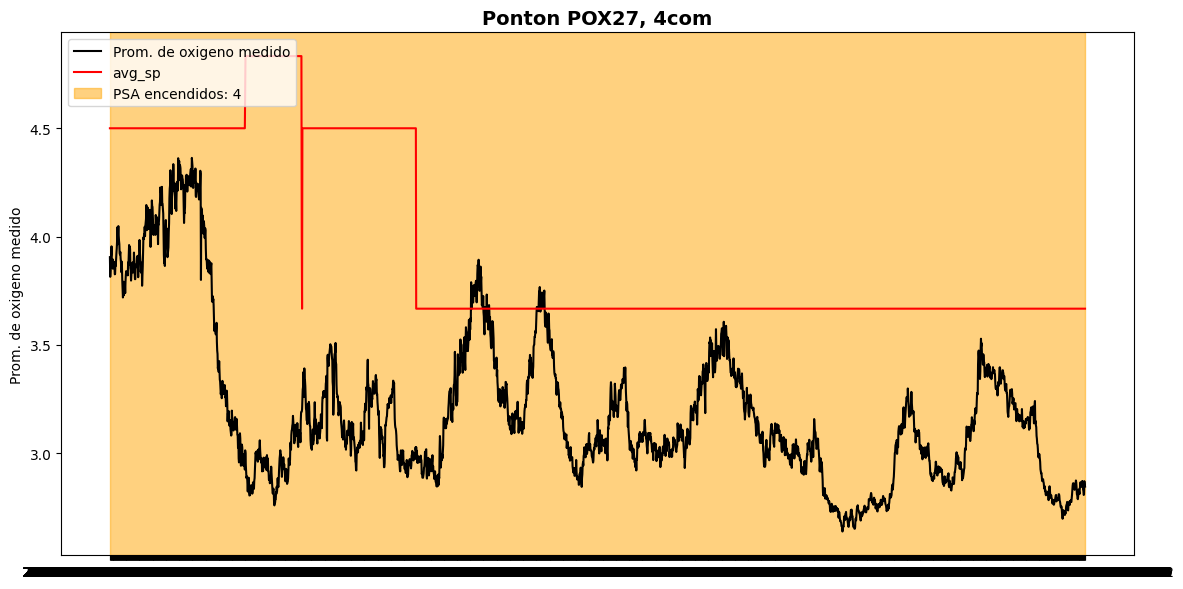

C:\Users\felip\AppData\Local\Temp\ipykernel_24880\2587497079.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grupo'] = (df['suma_psa'] != df['suma_psa'].shift()).cumsum()


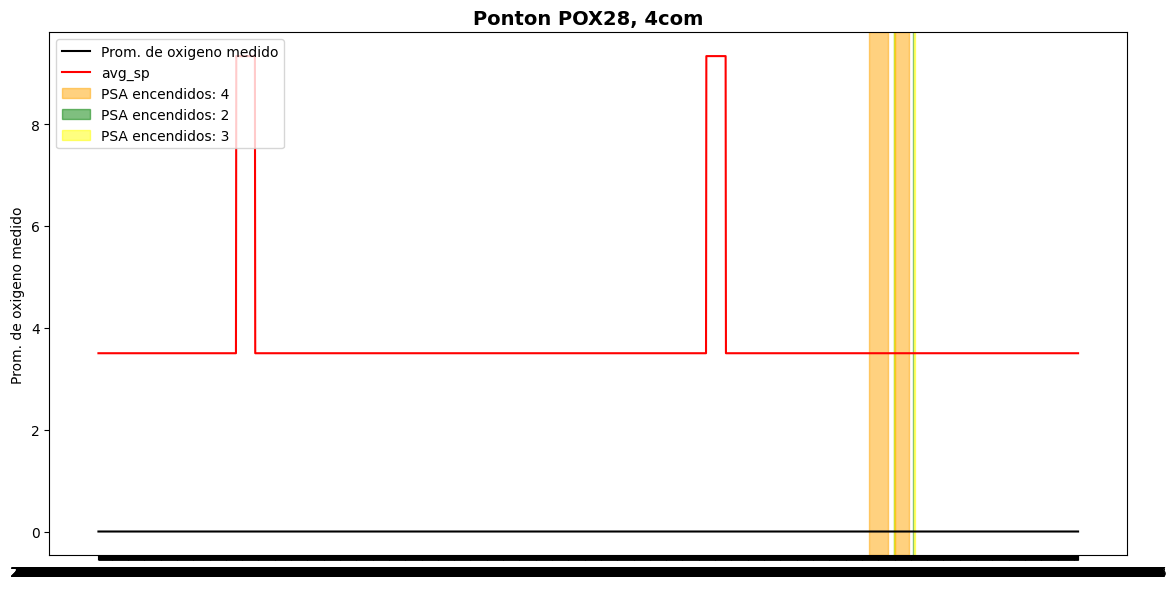

C:\Users\felip\AppData\Local\Temp\ipykernel_24880\2587497079.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grupo'] = (df['suma_psa'] != df['suma_psa'].shift()).cumsum()


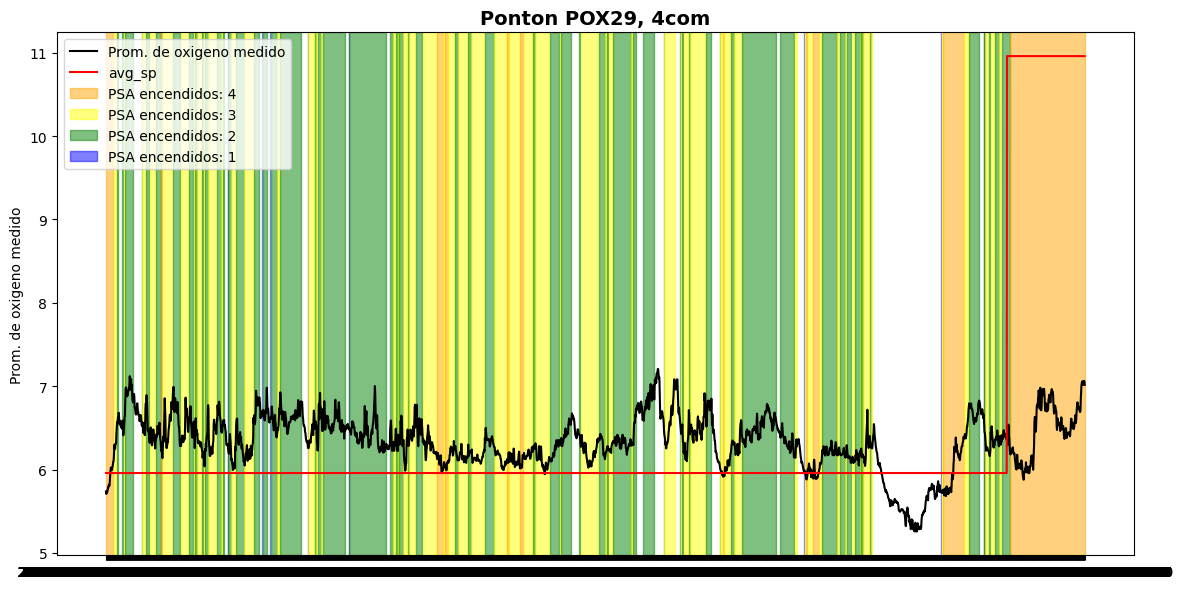

C:\Users\felip\AppData\Local\Temp\ipykernel_24880\2587497079.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grupo'] = (df['suma_psa'] != df['suma_psa'].shift()).cumsum()


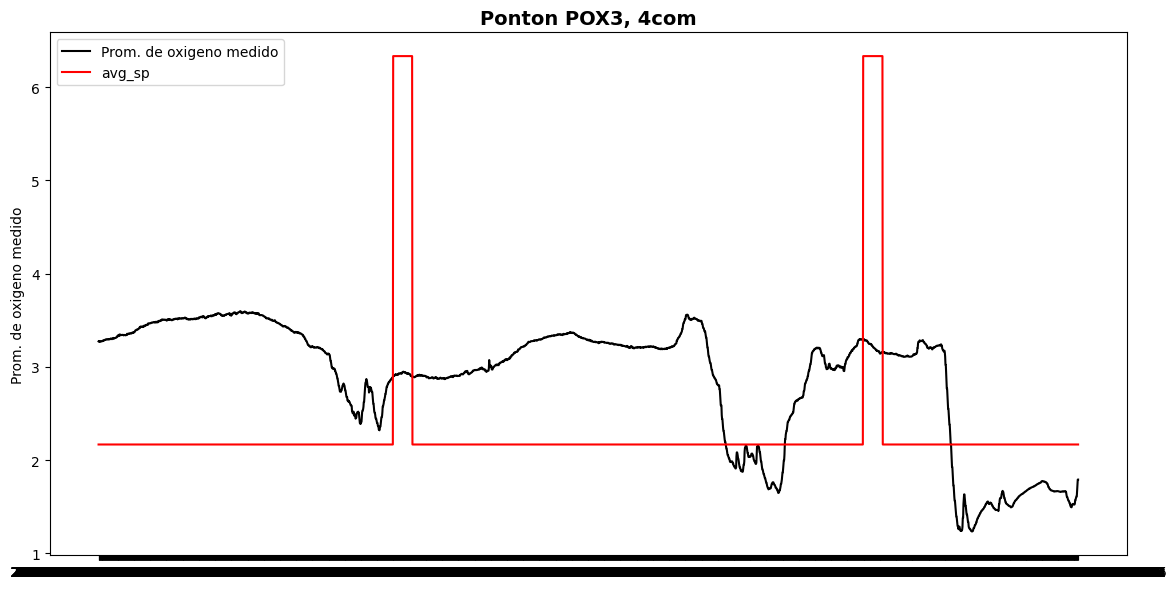

C:\Users\felip\AppData\Local\Temp\ipykernel_24880\2587497079.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grupo'] = (df['suma_psa'] != df['suma_psa'].shift()).cumsum()


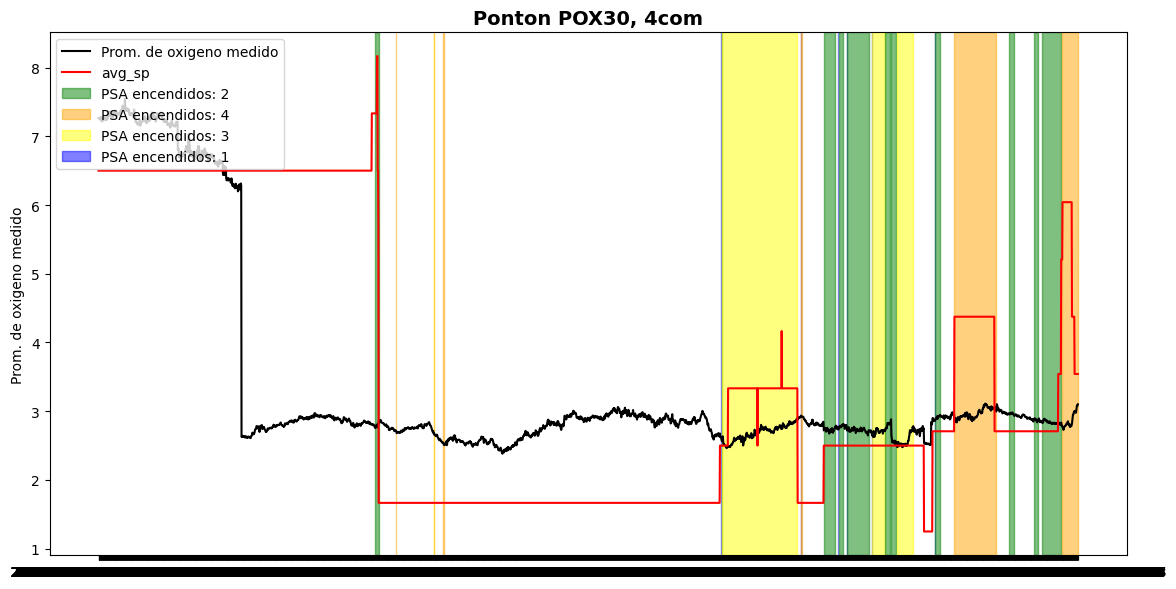

C:\Users\felip\AppData\Local\Temp\ipykernel_24880\2587497079.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grupo'] = (df['suma_psa'] != df['suma_psa'].shift()).cumsum()


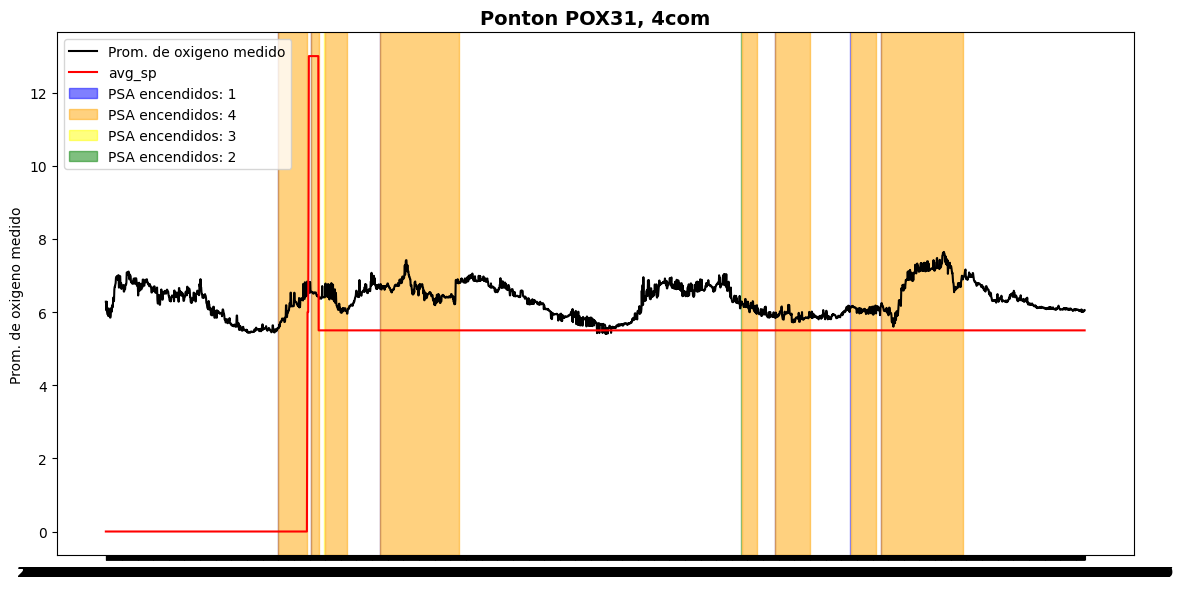

C:\Users\felip\AppData\Local\Temp\ipykernel_24880\2587497079.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grupo'] = (df['suma_psa'] != df['suma_psa'].shift()).cumsum()


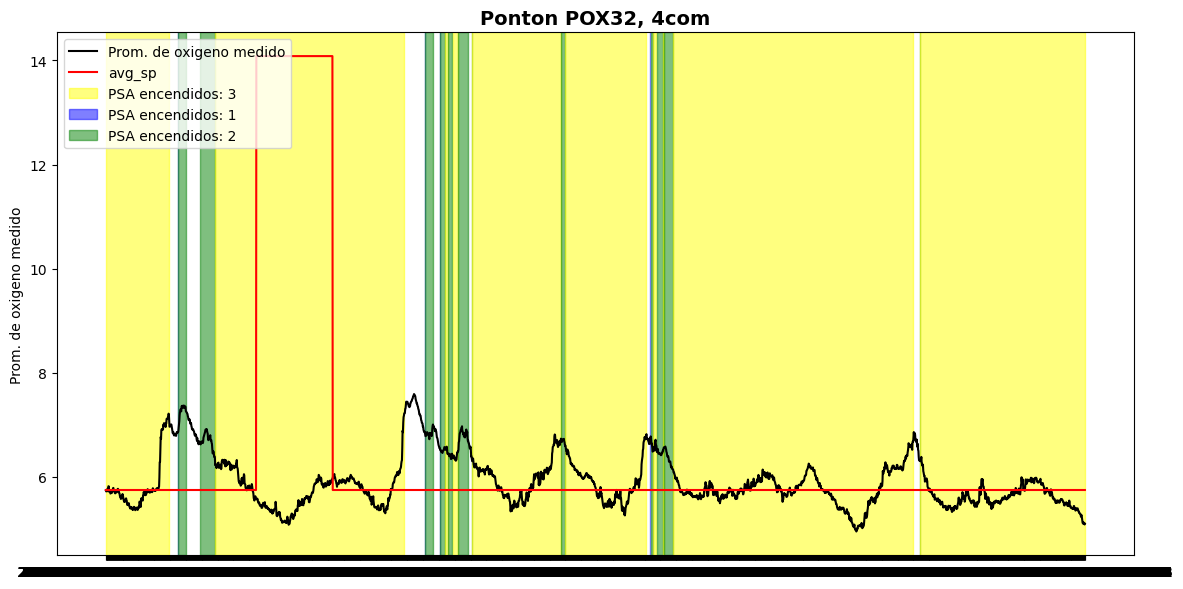

C:\Users\felip\AppData\Local\Temp\ipykernel_24880\2587497079.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grupo'] = (df['suma_psa'] != df['suma_psa'].shift()).cumsum()


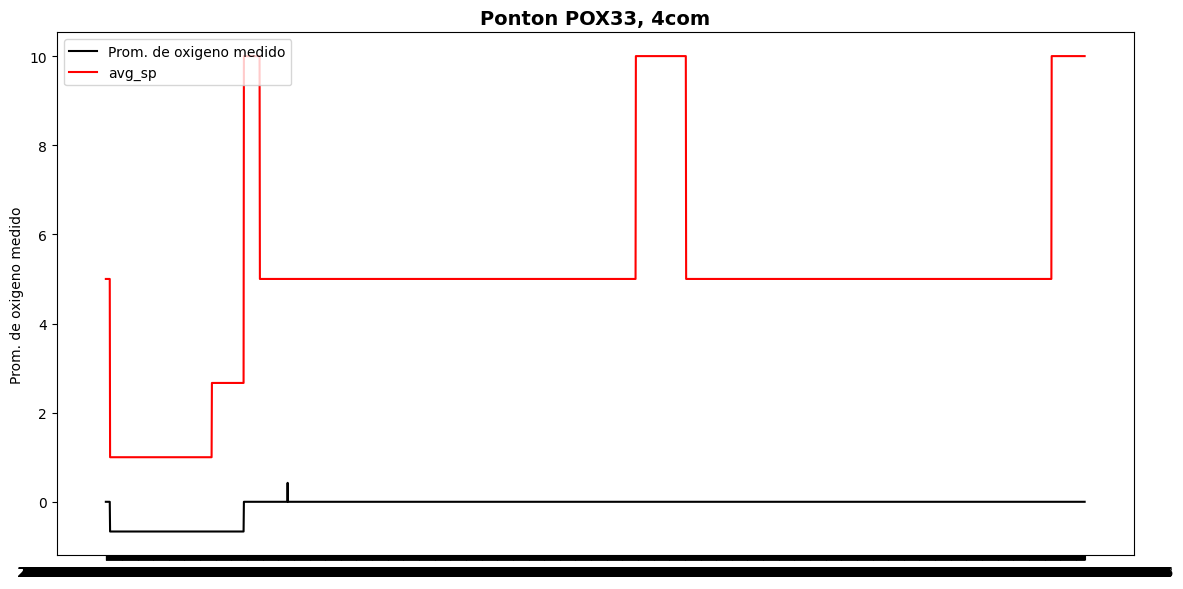

C:\Users\felip\AppData\Local\Temp\ipykernel_24880\2587497079.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grupo'] = (df['suma_psa'] != df['suma_psa'].shift()).cumsum()


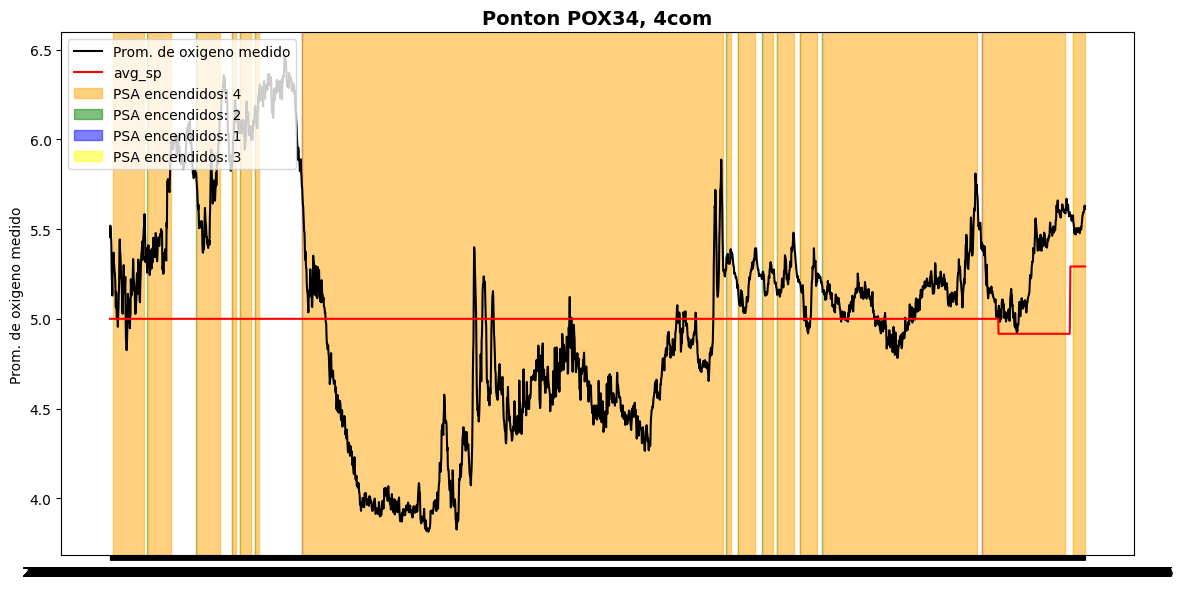

C:\Users\felip\AppData\Local\Temp\ipykernel_24880\2587497079.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grupo'] = (df['suma_psa'] != df['suma_psa'].shift()).cumsum()


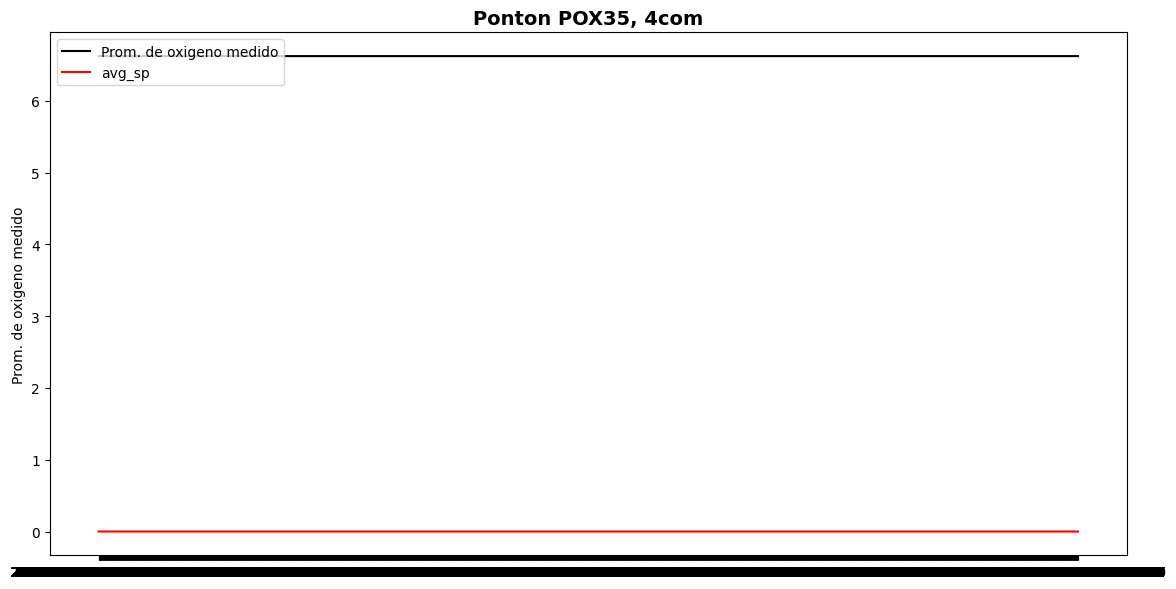

C:\Users\felip\AppData\Local\Temp\ipykernel_24880\2587497079.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grupo'] = (df['suma_psa'] != df['suma_psa'].shift()).cumsum()


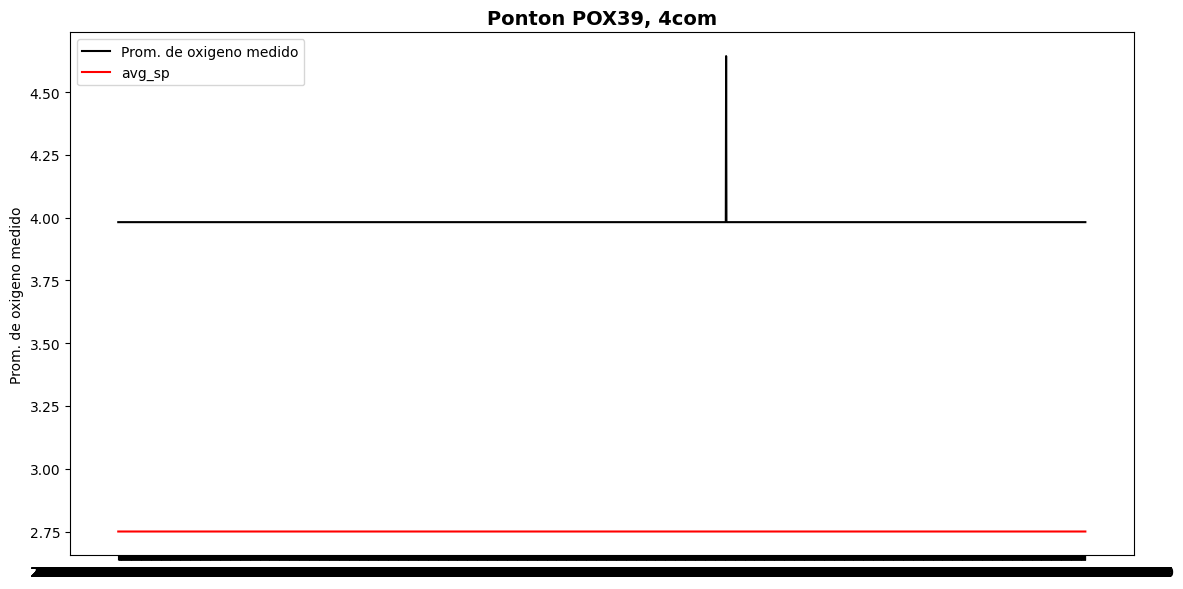

C:\Users\felip\AppData\Local\Temp\ipykernel_24880\2587497079.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grupo'] = (df['suma_psa'] != df['suma_psa'].shift()).cumsum()


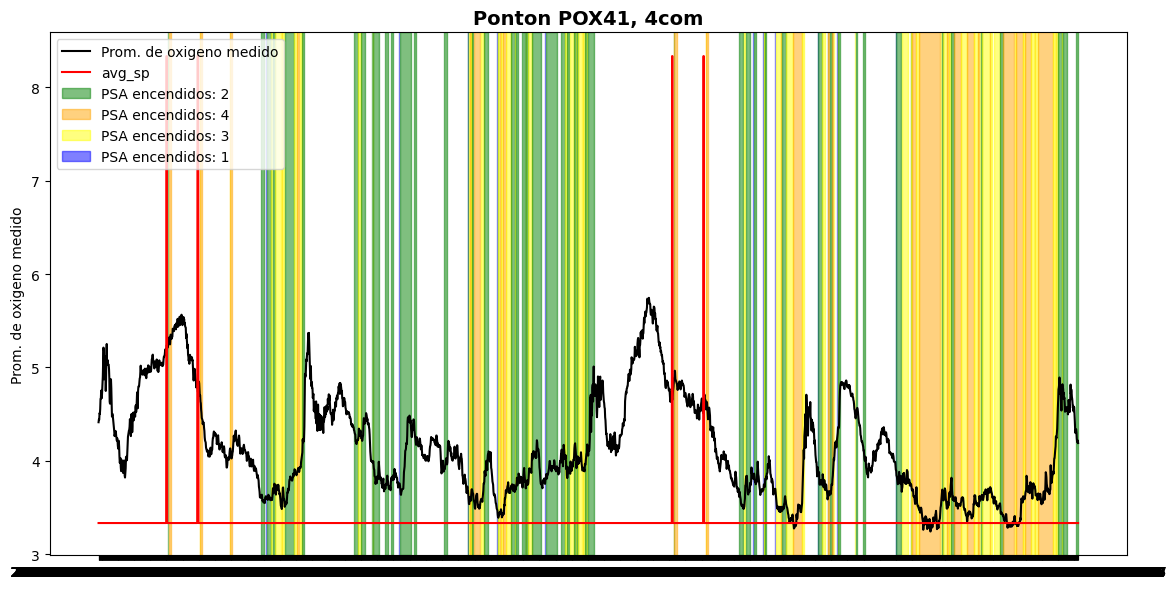

C:\Users\felip\AppData\Local\Temp\ipykernel_24880\2587497079.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grupo'] = (df['suma_psa'] != df['suma_psa'].shift()).cumsum()


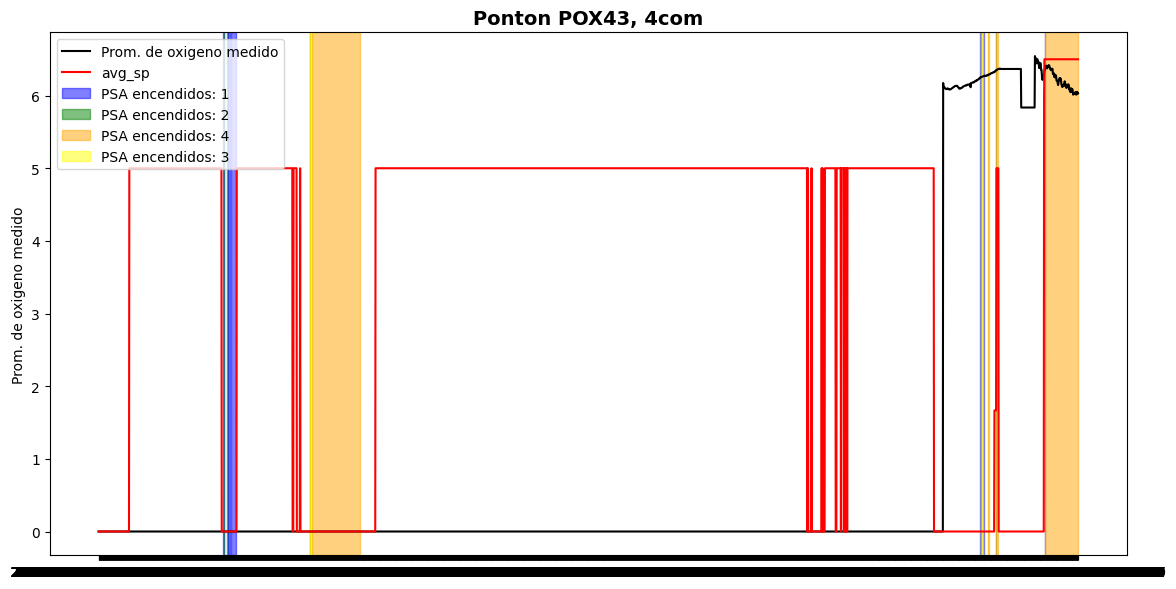

C:\Users\felip\AppData\Local\Temp\ipykernel_24880\2587497079.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grupo'] = (df['suma_psa'] != df['suma_psa'].shift()).cumsum()


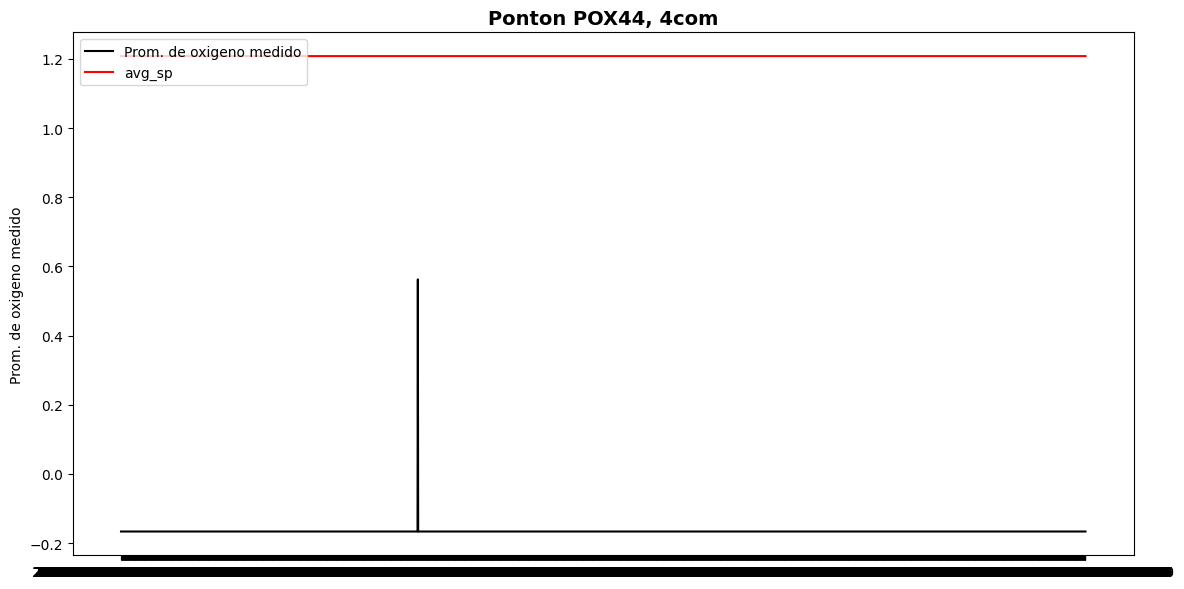

C:\Users\felip\AppData\Local\Temp\ipykernel_24880\2587497079.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grupo'] = (df['suma_psa'] != df['suma_psa'].shift()).cumsum()


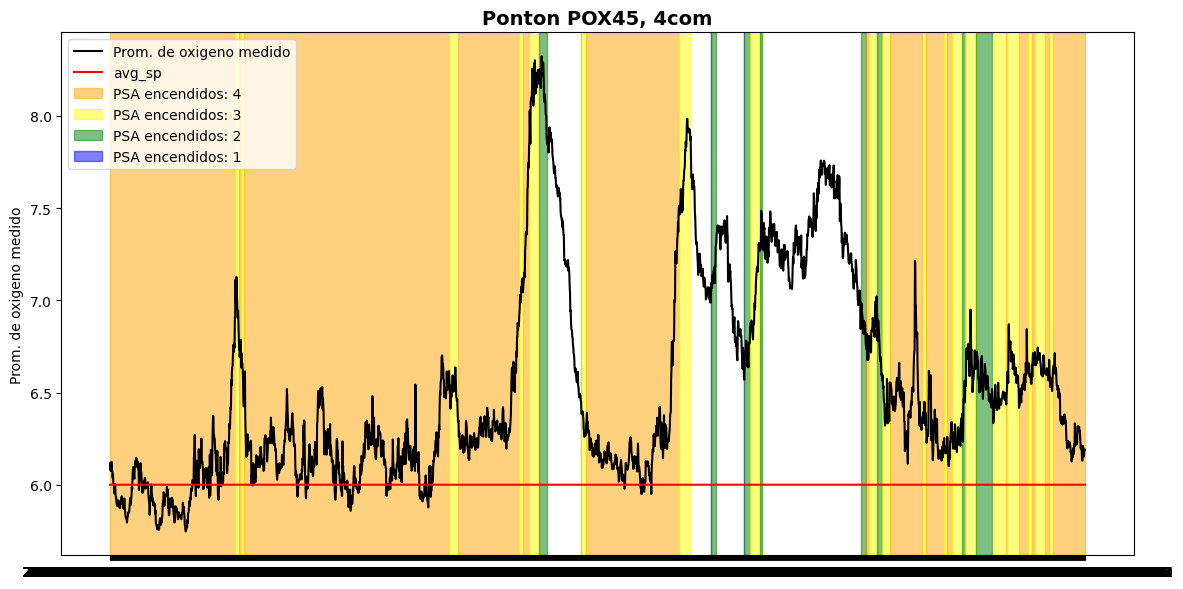

C:\Users\felip\AppData\Local\Temp\ipykernel_24880\2587497079.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grupo'] = (df['suma_psa'] != df['suma_psa'].shift()).cumsum()


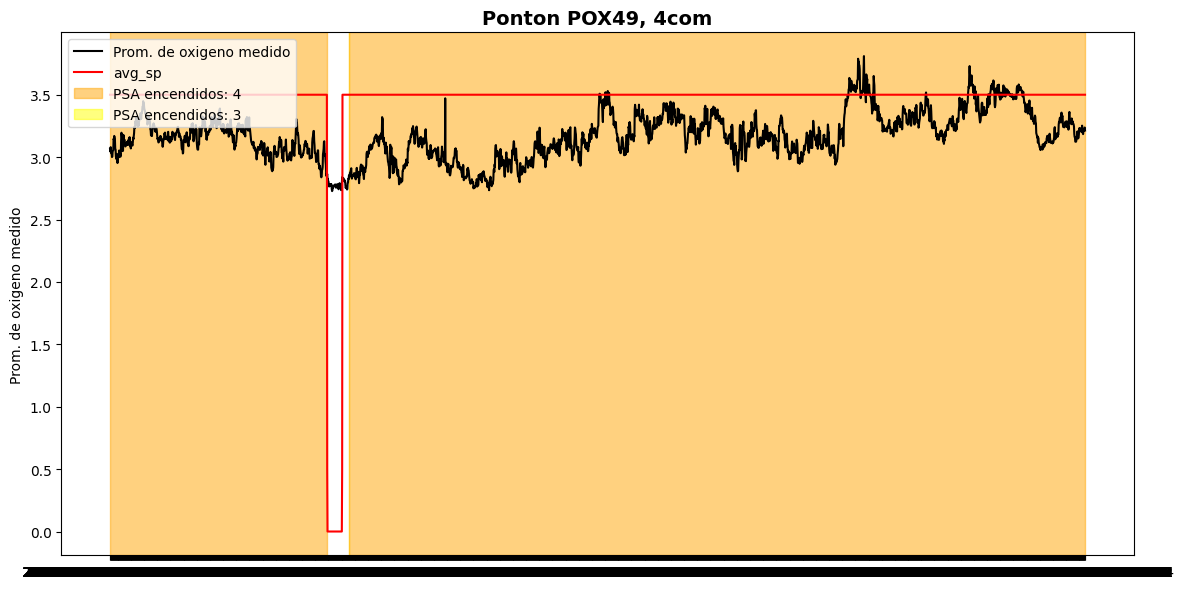

C:\Users\felip\AppData\Local\Temp\ipykernel_24880\2587497079.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grupo'] = (df['suma_psa'] != df['suma_psa'].shift()).cumsum()


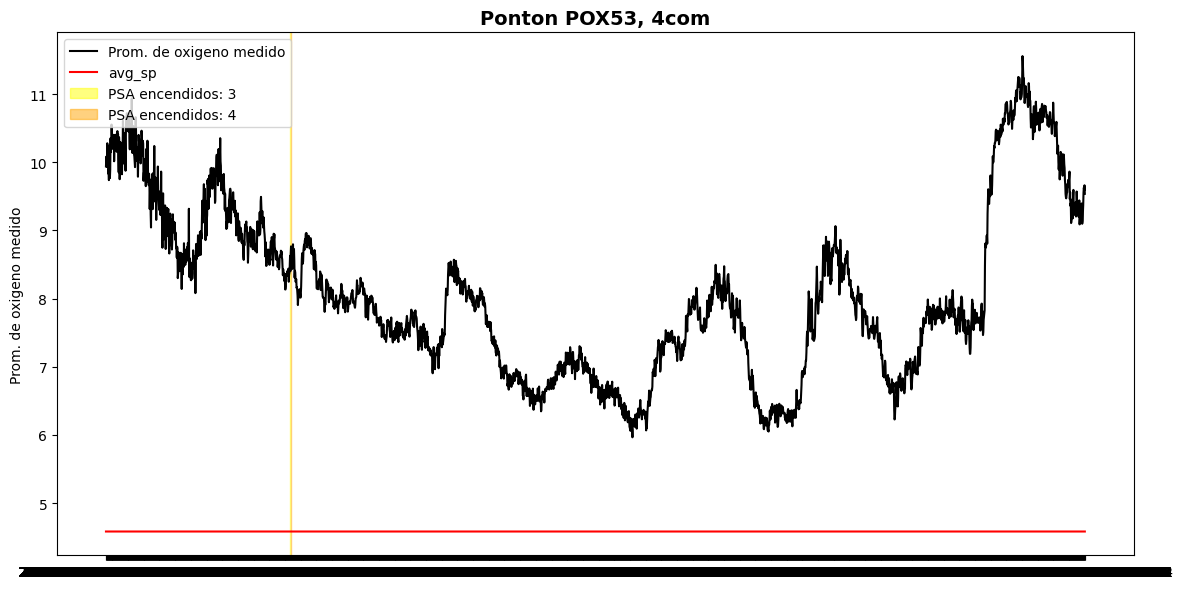

C:\Users\felip\AppData\Local\Temp\ipykernel_24880\2587497079.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grupo'] = (df['suma_psa'] != df['suma_psa'].shift()).cumsum()


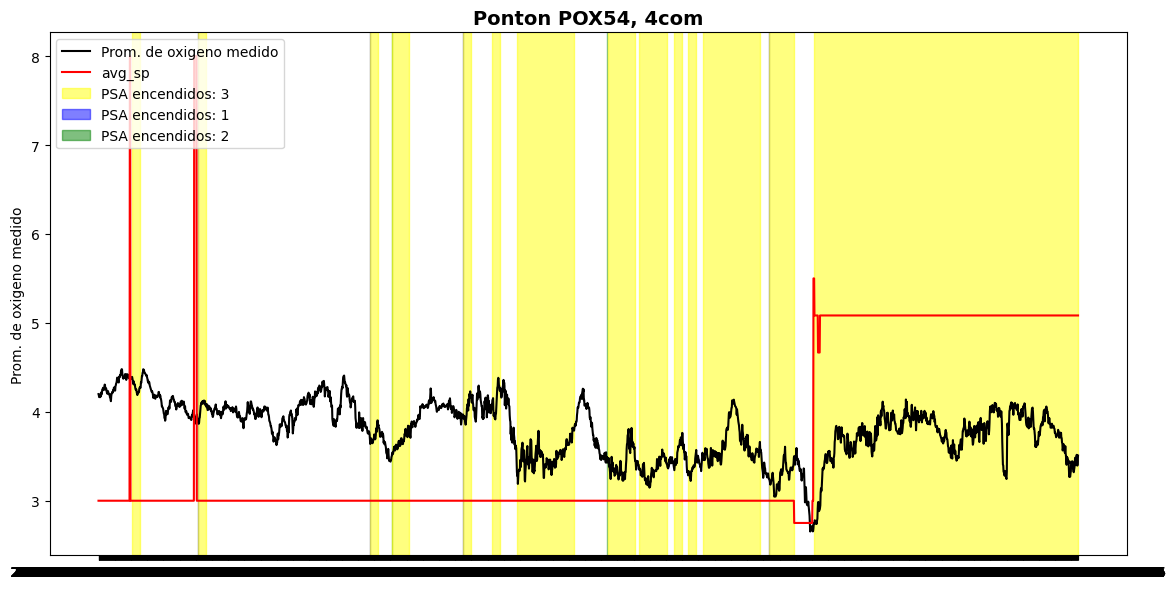

C:\Users\felip\AppData\Local\Temp\ipykernel_24880\2587497079.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grupo'] = (df['suma_psa'] != df['suma_psa'].shift()).cumsum()


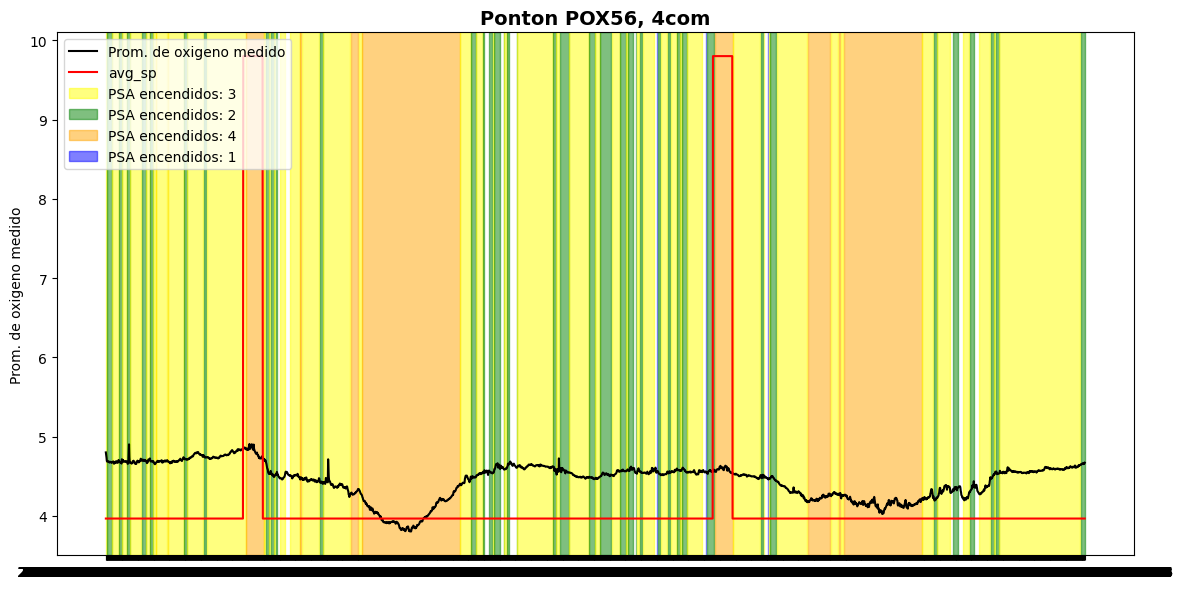

C:\Users\felip\AppData\Local\Temp\ipykernel_24880\2587497079.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grupo'] = (df['suma_psa'] != df['suma_psa'].shift()).cumsum()


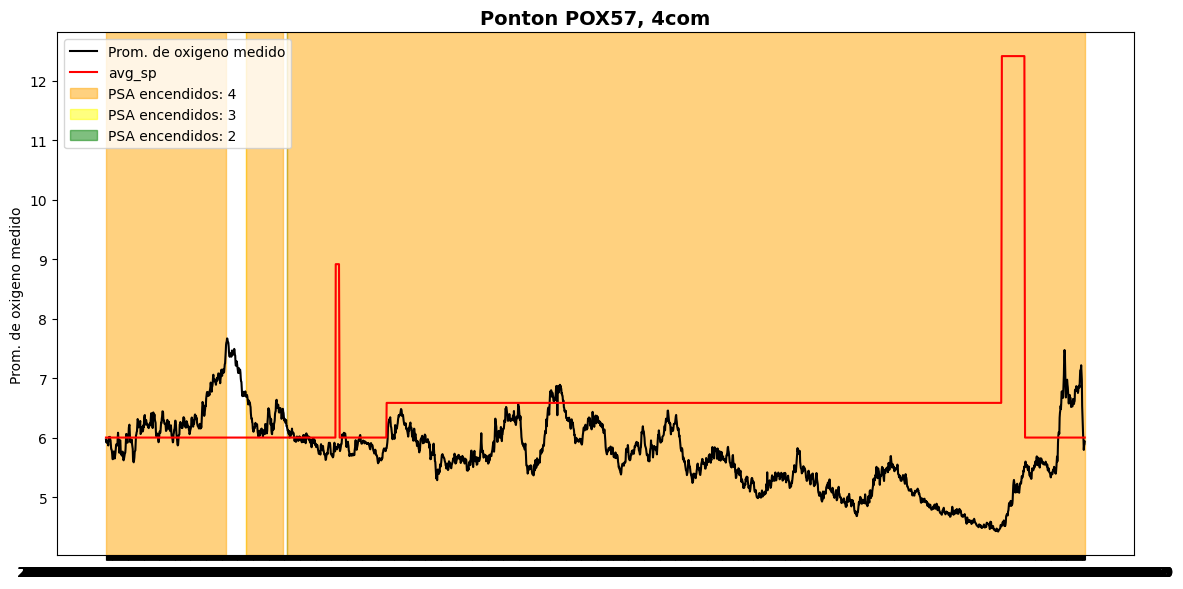

C:\Users\felip\AppData\Local\Temp\ipykernel_24880\2587497079.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grupo'] = (df['suma_psa'] != df['suma_psa'].shift()).cumsum()


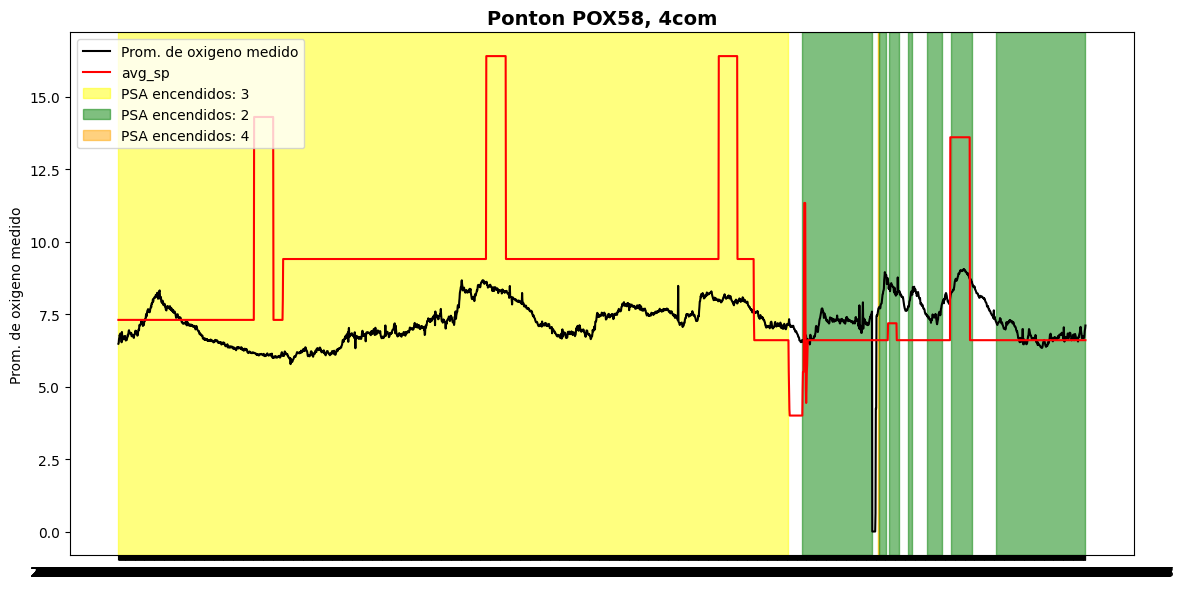

C:\Users\felip\AppData\Local\Temp\ipykernel_24880\2587497079.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grupo'] = (df['suma_psa'] != df['suma_psa'].shift()).cumsum()


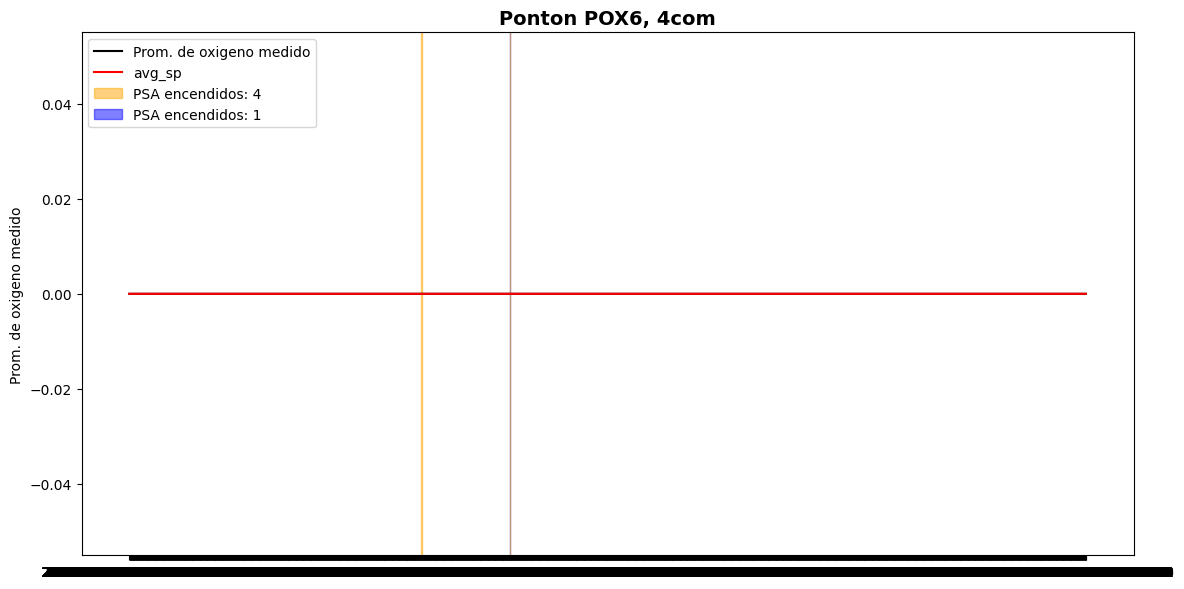

C:\Users\felip\AppData\Local\Temp\ipykernel_24880\2587497079.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grupo'] = (df['suma_psa'] != df['suma_psa'].shift()).cumsum()


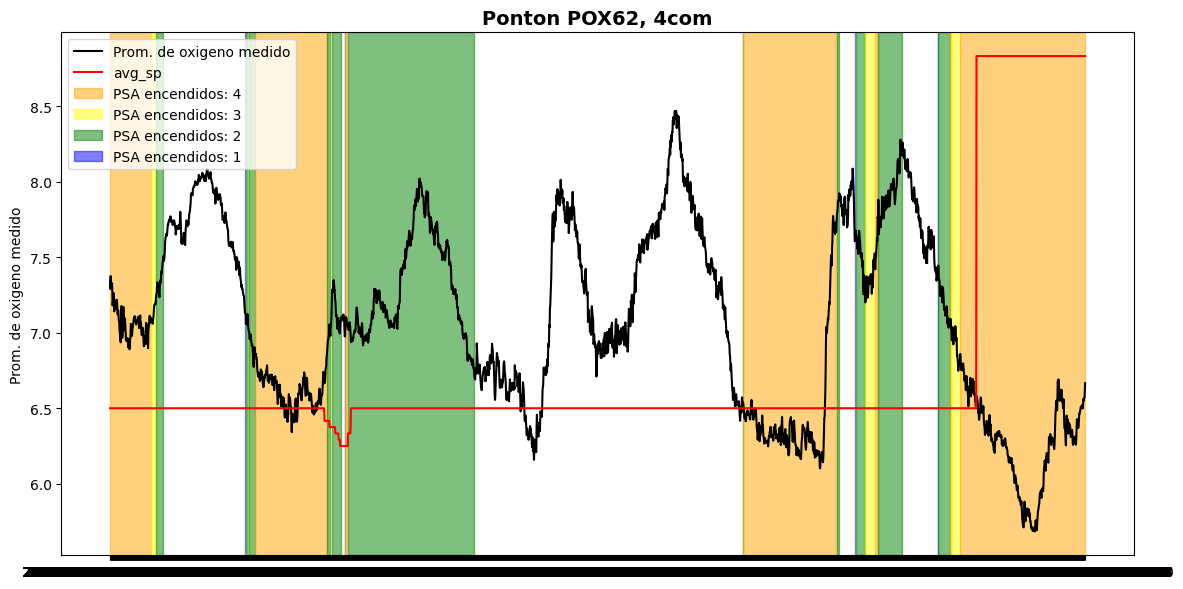

C:\Users\felip\AppData\Local\Temp\ipykernel_24880\2587497079.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grupo'] = (df['suma_psa'] != df['suma_psa'].shift()).cumsum()


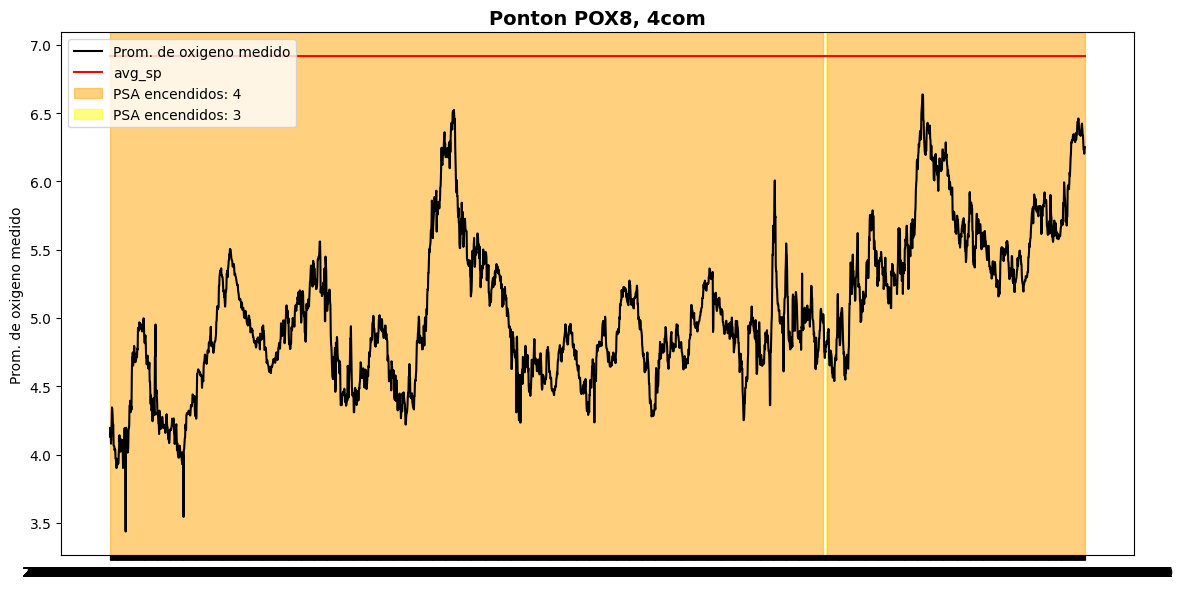

C:\Users\felip\AppData\Local\Temp\ipykernel_24880\2587497079.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grupo'] = (df['suma_psa'] != df['suma_psa'].shift()).cumsum()


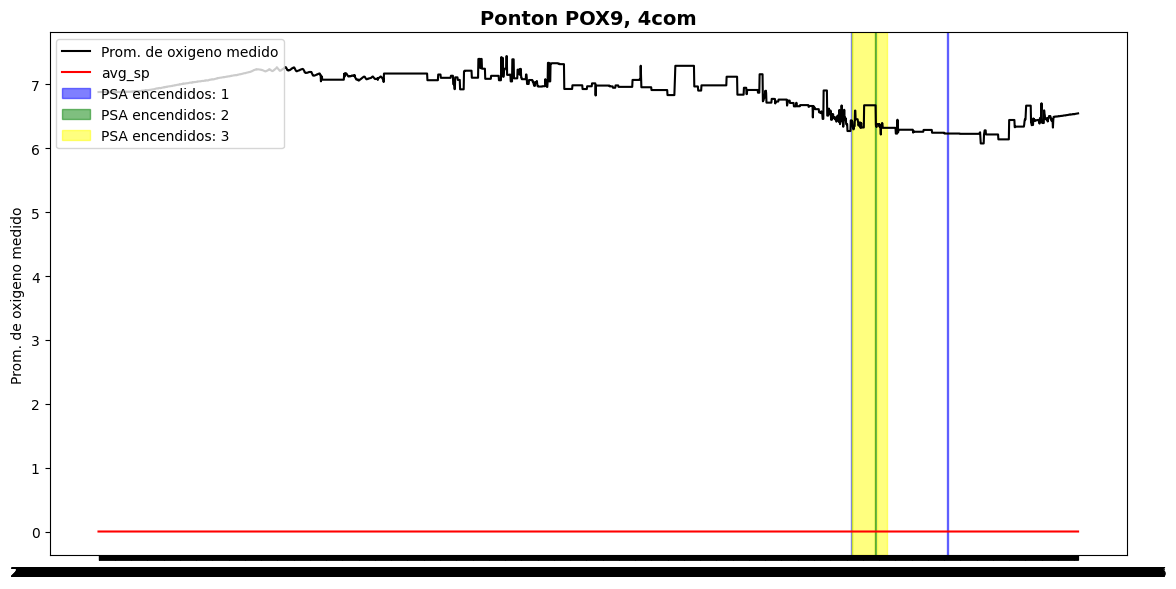

C:\Users\felip\AppData\Local\Temp\ipykernel_24880\2587497079.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grupo'] = (df['suma_psa'] != df['suma_psa'].shift()).cumsum()


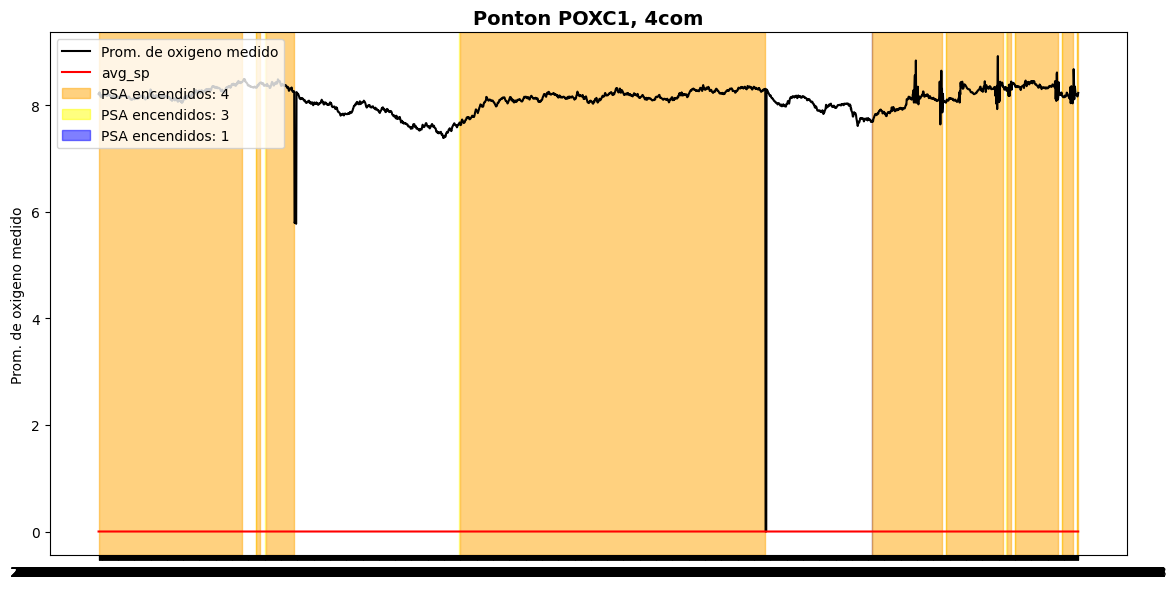

In [8]:
for x in ['POX10', 'POX11', 'POX13', 'POX15', 'POX16', 'POX17', 'POX18', 'POX19', 'POX20', 'POX21', 'POX22', 'POX23', 'POX24', 'POX25', 'POX26', 'POX27', 'POX28', 'POX29', 'POX3', 'POX30', 'POX31', 'POX32', 'POX33', 'POX34', 'POX35', 'POX39', 'POX41', 'POX43', 'POX44', 'POX45', 'POX49', 'POX53', 'POX54', 'POX56', 'POX57', 'POX58', 'POX6', 'POX62', 'POX8', 'POX9', 'POXC1']:
    graph(sub_dfs_comp4[x], title=f"Ponton {x}, 4com", ammount=3000)


C:\Users\felip\AppData\Local\Temp\ipykernel_24880\2587497079.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grupo'] = (df['suma_psa'] != df['suma_psa'].shift()).cumsum()


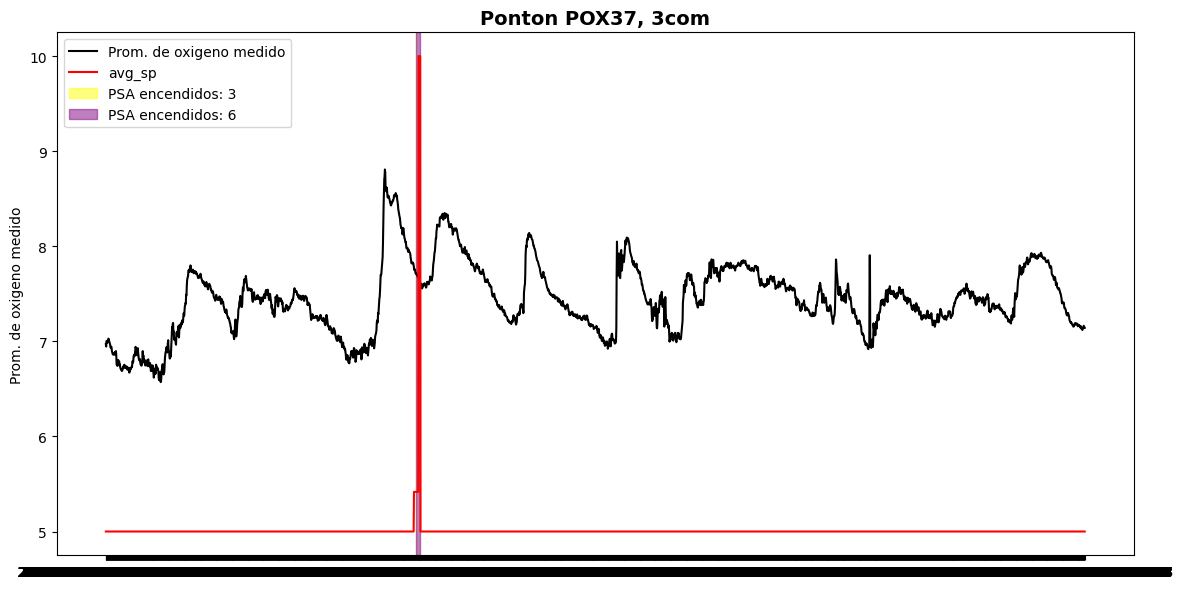

C:\Users\felip\AppData\Local\Temp\ipykernel_24880\2587497079.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grupo'] = (df['suma_psa'] != df['suma_psa'].shift()).cumsum()


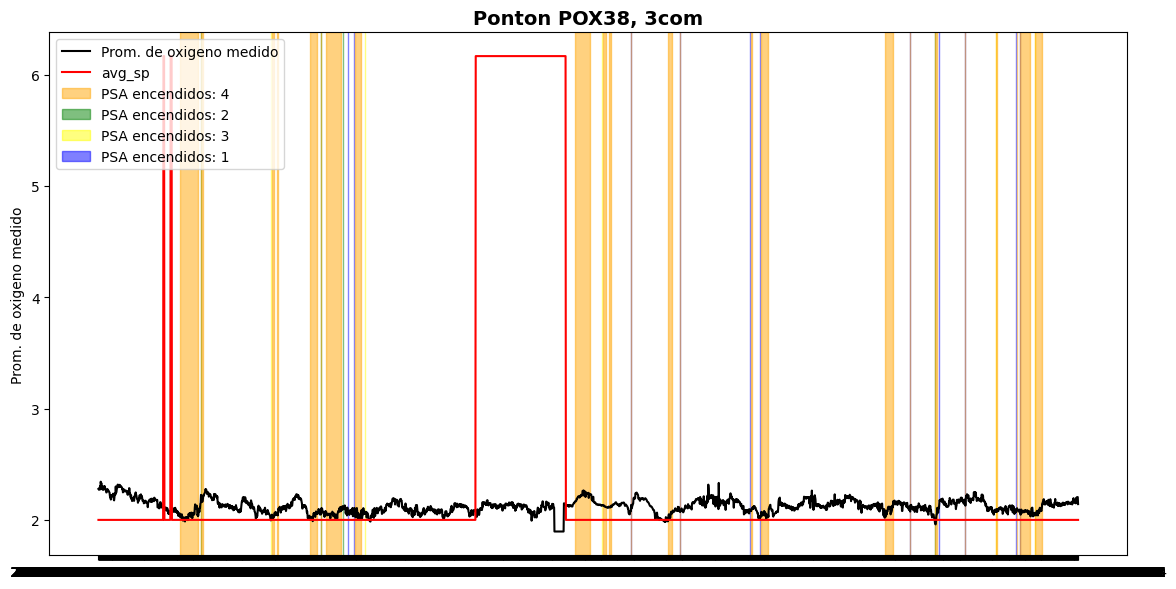

C:\Users\felip\AppData\Local\Temp\ipykernel_24880\2587497079.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grupo'] = (df['suma_psa'] != df['suma_psa'].shift()).cumsum()


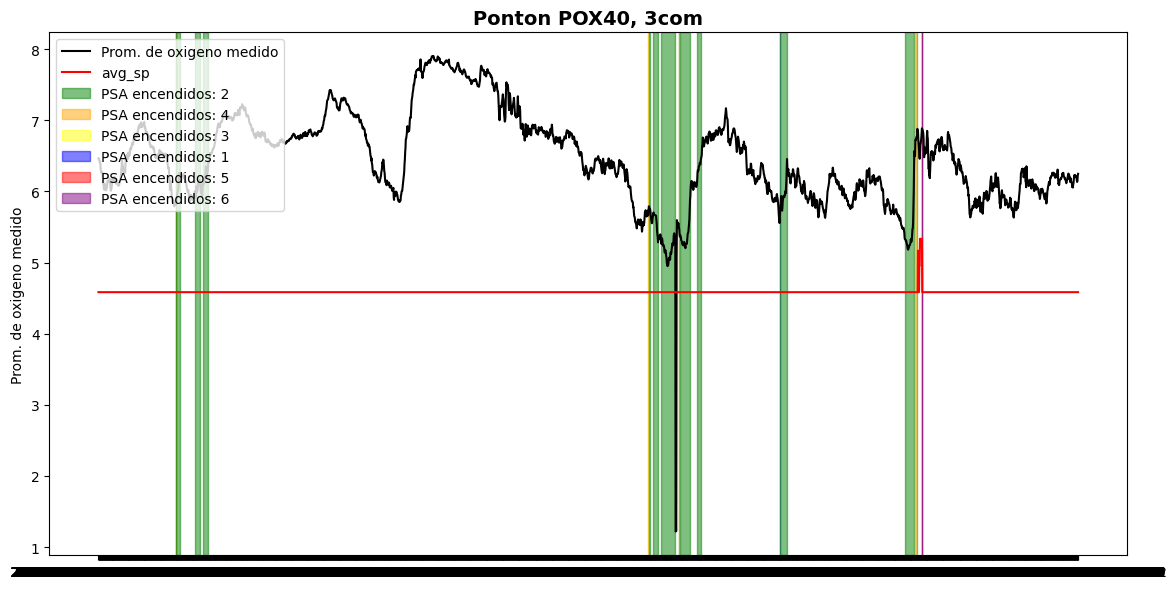

C:\Users\felip\AppData\Local\Temp\ipykernel_24880\2587497079.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grupo'] = (df['suma_psa'] != df['suma_psa'].shift()).cumsum()


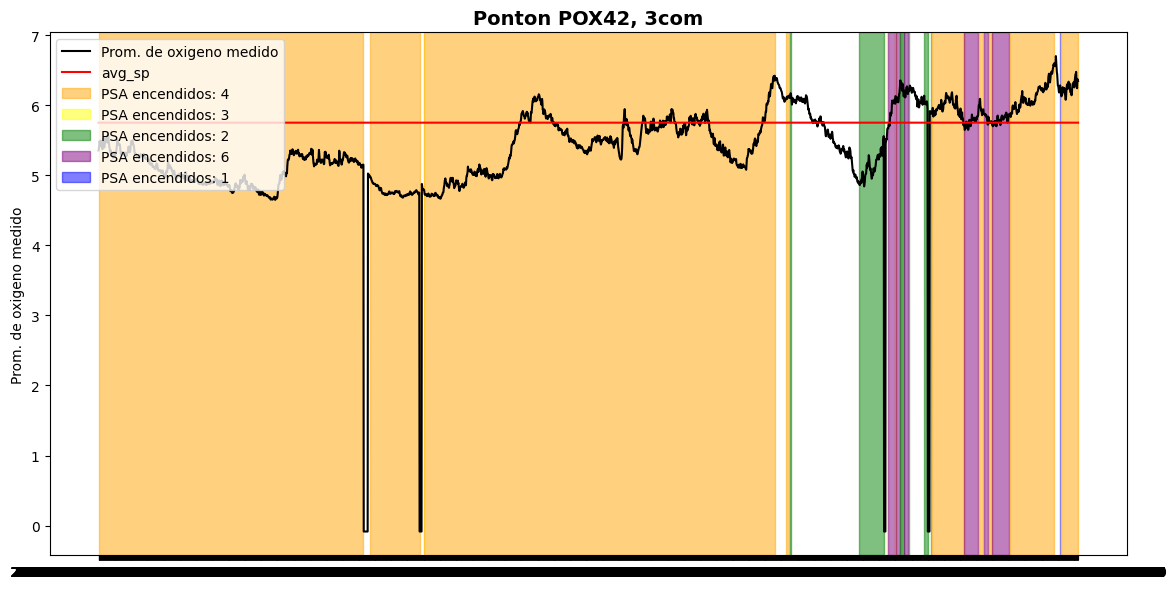

C:\Users\felip\AppData\Local\Temp\ipykernel_24880\2587497079.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grupo'] = (df['suma_psa'] != df['suma_psa'].shift()).cumsum()


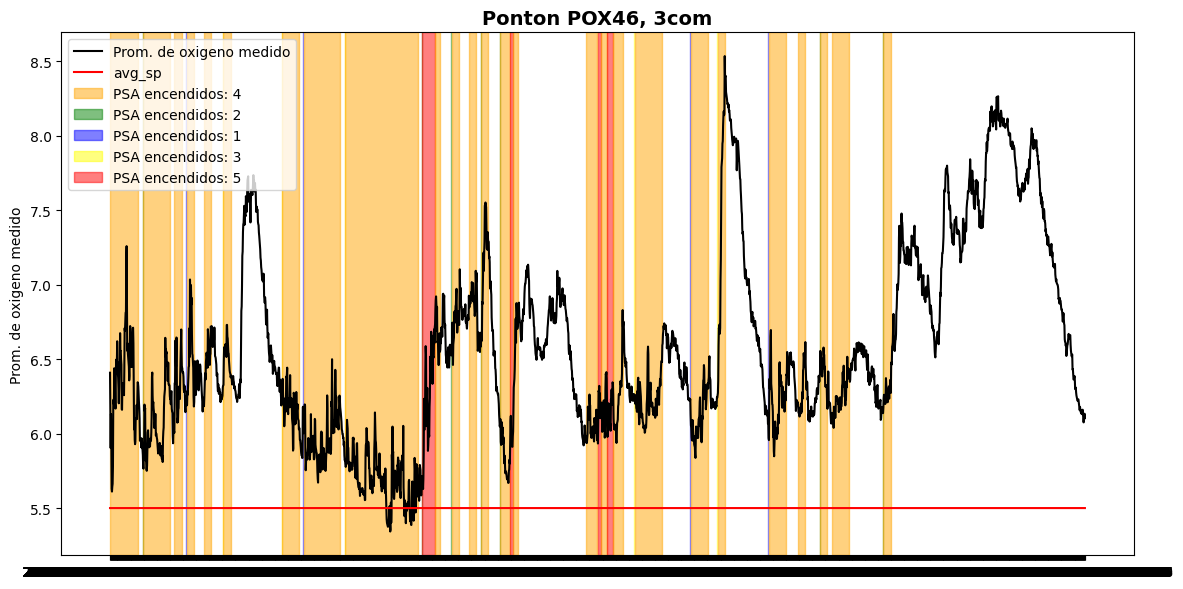

C:\Users\felip\AppData\Local\Temp\ipykernel_24880\2587497079.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grupo'] = (df['suma_psa'] != df['suma_psa'].shift()).cumsum()


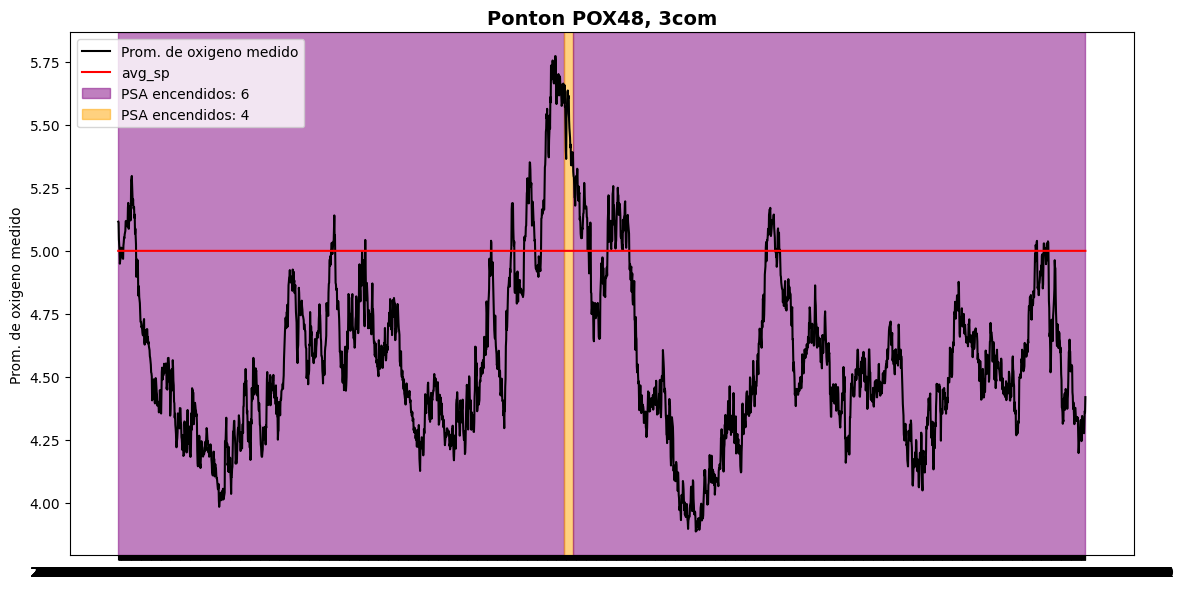

C:\Users\felip\AppData\Local\Temp\ipykernel_24880\2587497079.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grupo'] = (df['suma_psa'] != df['suma_psa'].shift()).cumsum()


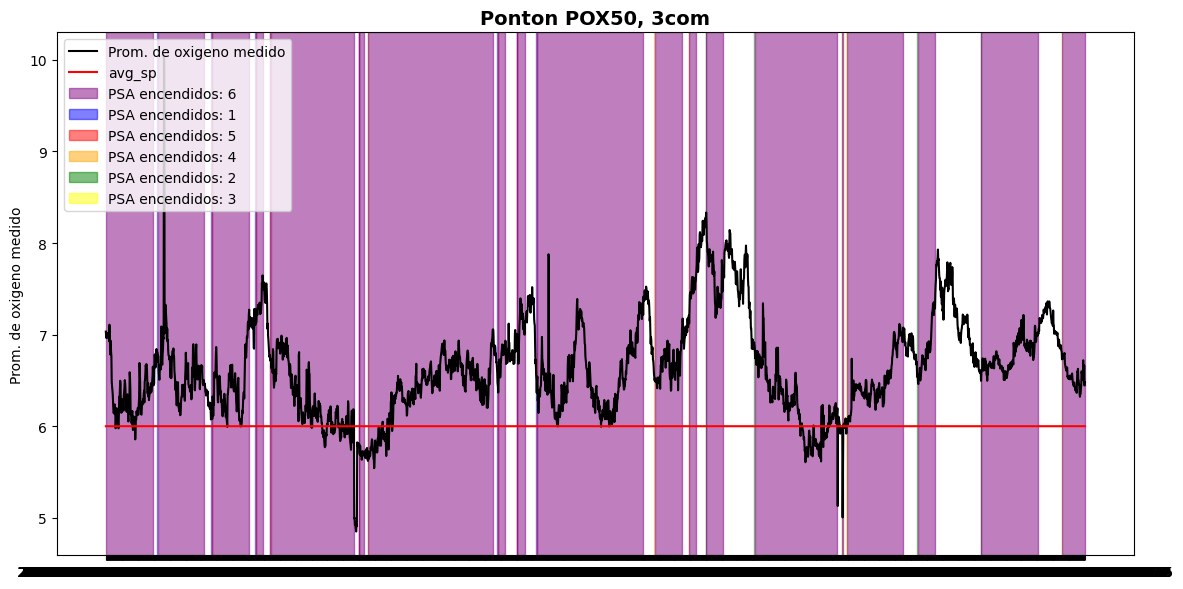

C:\Users\felip\AppData\Local\Temp\ipykernel_24880\2587497079.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grupo'] = (df['suma_psa'] != df['suma_psa'].shift()).cumsum()


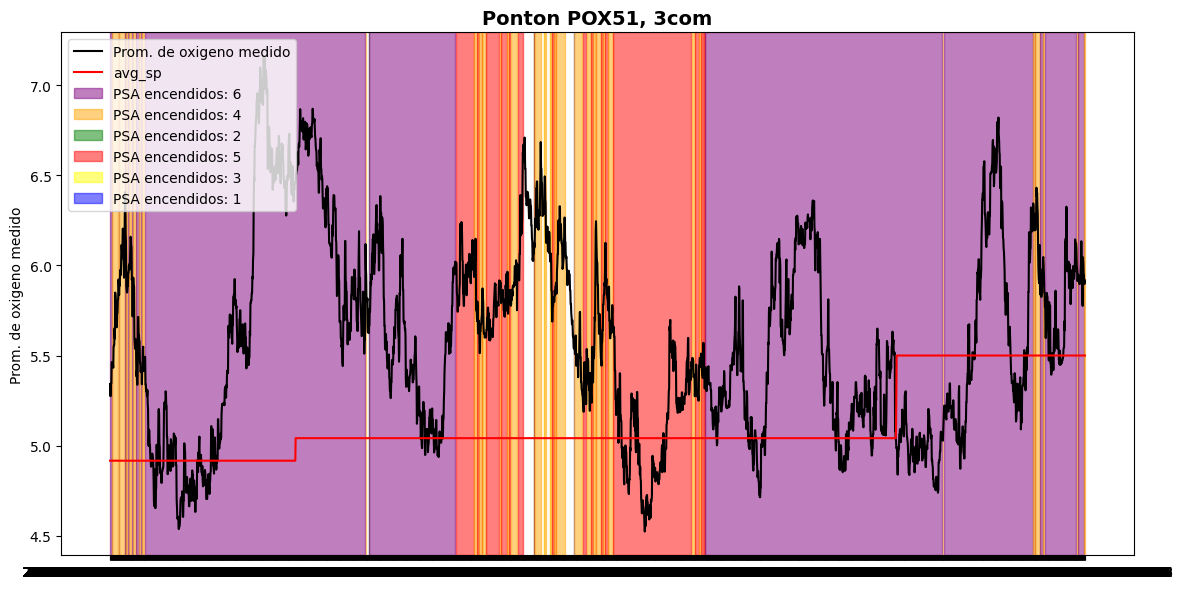

C:\Users\felip\AppData\Local\Temp\ipykernel_24880\2587497079.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grupo'] = (df['suma_psa'] != df['suma_psa'].shift()).cumsum()


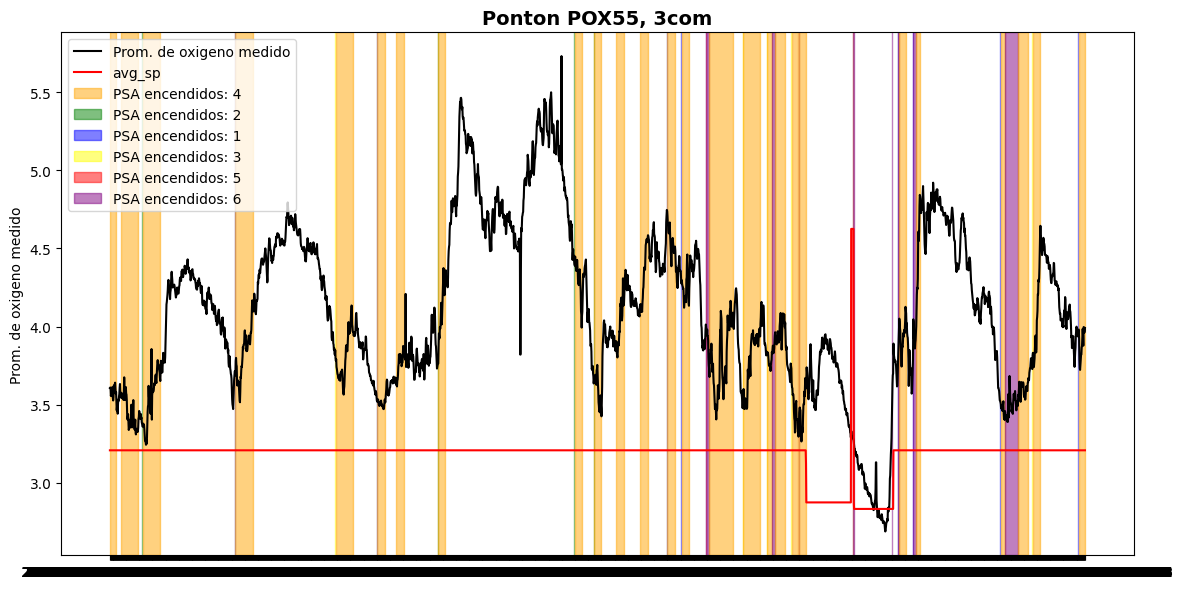

C:\Users\felip\AppData\Local\Temp\ipykernel_24880\2587497079.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grupo'] = (df['suma_psa'] != df['suma_psa'].shift()).cumsum()


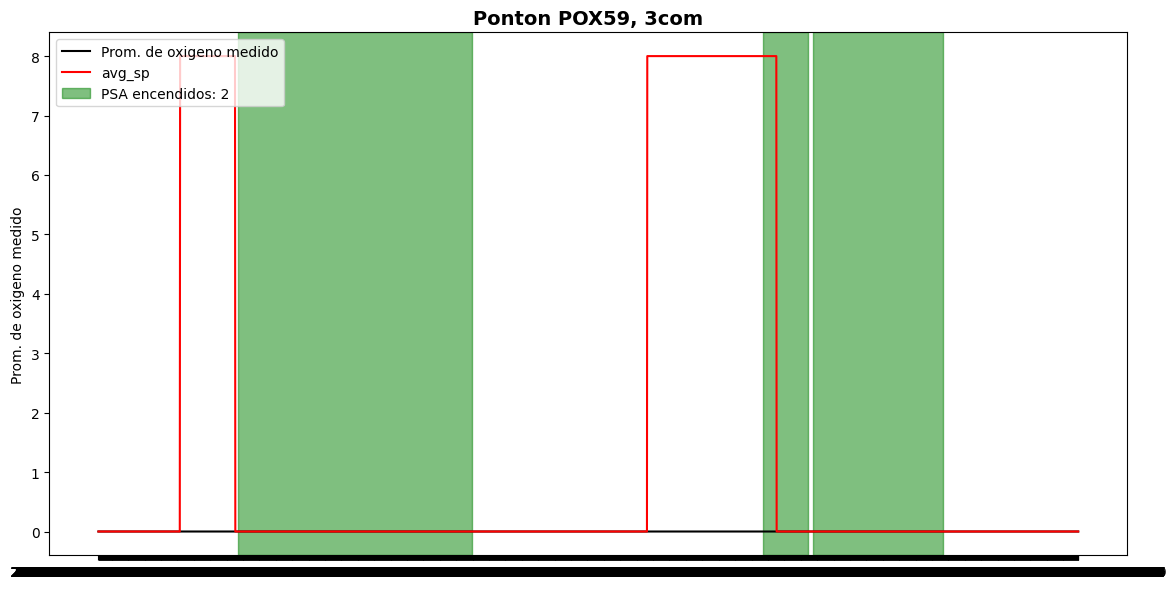

C:\Users\felip\AppData\Local\Temp\ipykernel_24880\2587497079.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grupo'] = (df['suma_psa'] != df['suma_psa'].shift()).cumsum()


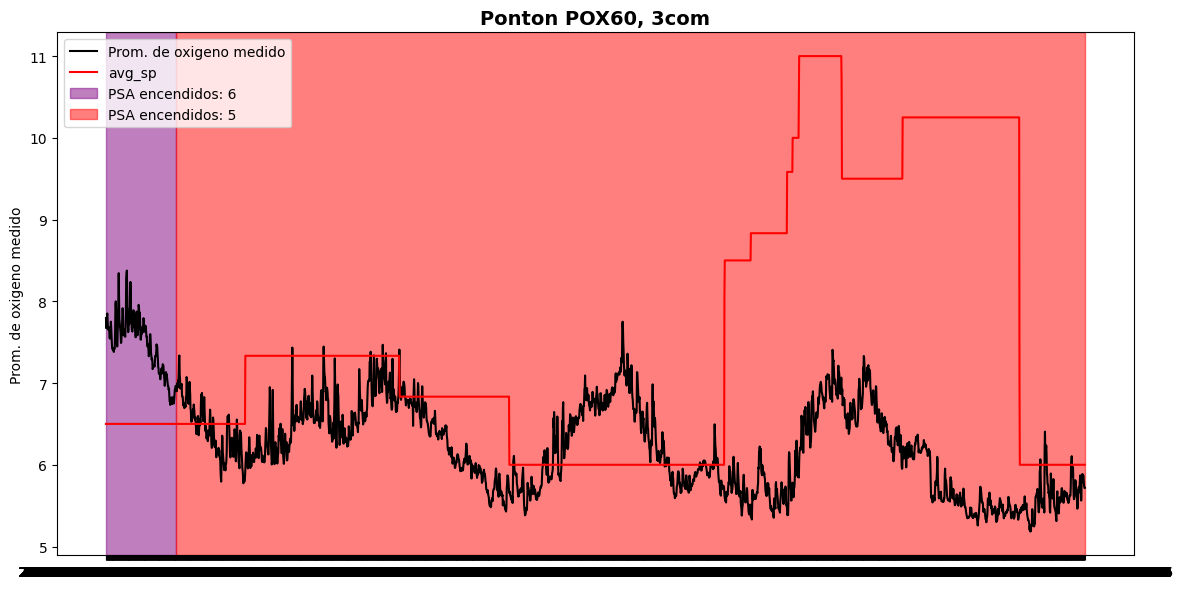

C:\Users\felip\AppData\Local\Temp\ipykernel_24880\2587497079.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grupo'] = (df['suma_psa'] != df['suma_psa'].shift()).cumsum()


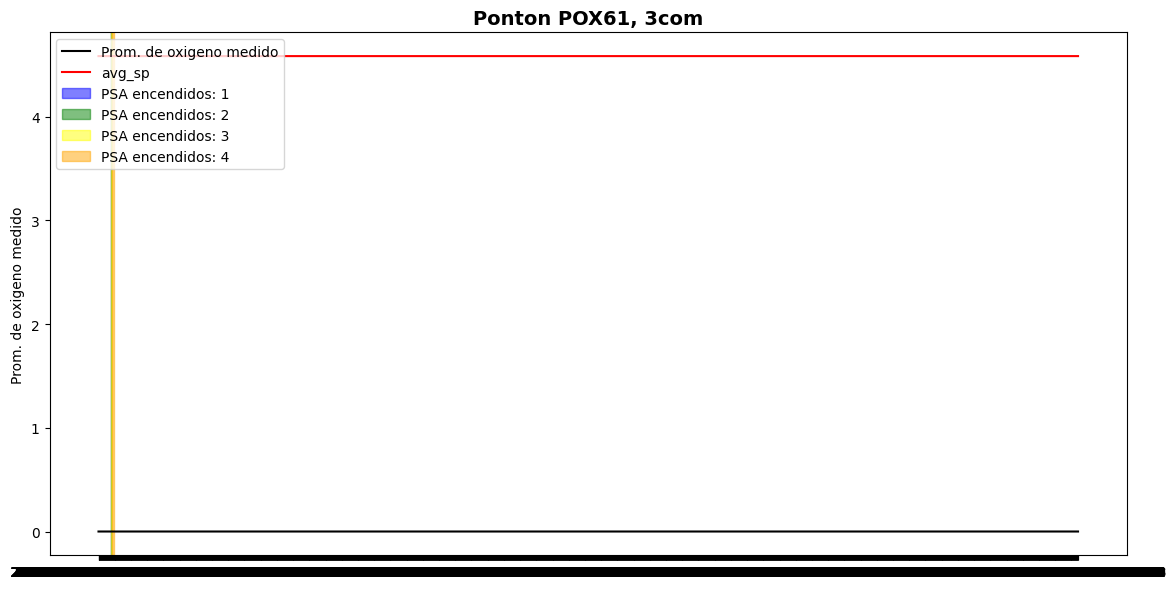

C:\Users\felip\AppData\Local\Temp\ipykernel_24880\2587497079.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grupo'] = (df['suma_psa'] != df['suma_psa'].shift()).cumsum()


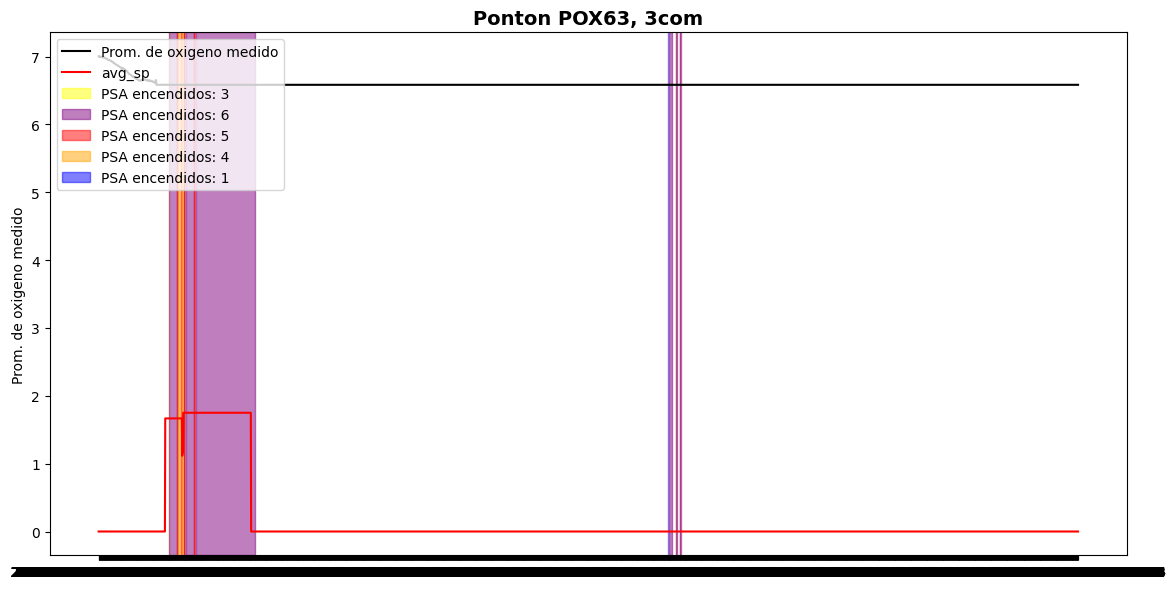

C:\Users\felip\AppData\Local\Temp\ipykernel_24880\2587497079.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grupo'] = (df['suma_psa'] != df['suma_psa'].shift()).cumsum()


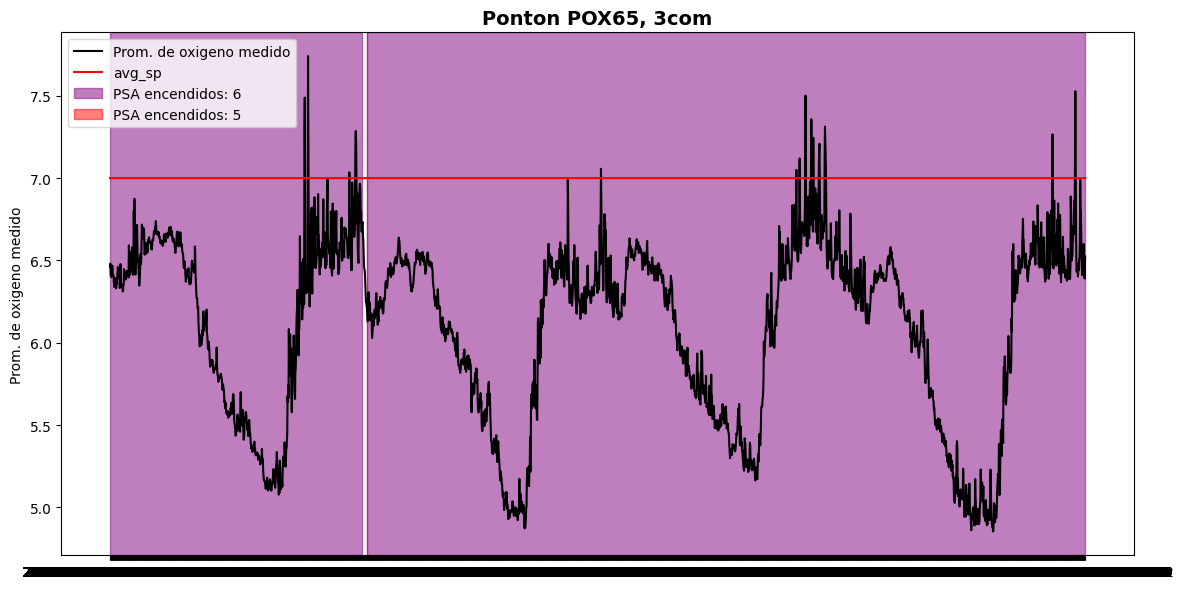

In [9]:
for x in ['POX37', 'POX38', 'POX40', 'POX42', 'POX46', 'POX48', 'POX50', 'POX51', 'POX55', 'POX59', 'POX60', 'POX61', 'POX63', 'POX65']:
    graph(sub_dfs_comp3[x], title=f"Ponton {x}, 3com", ammount=3000)


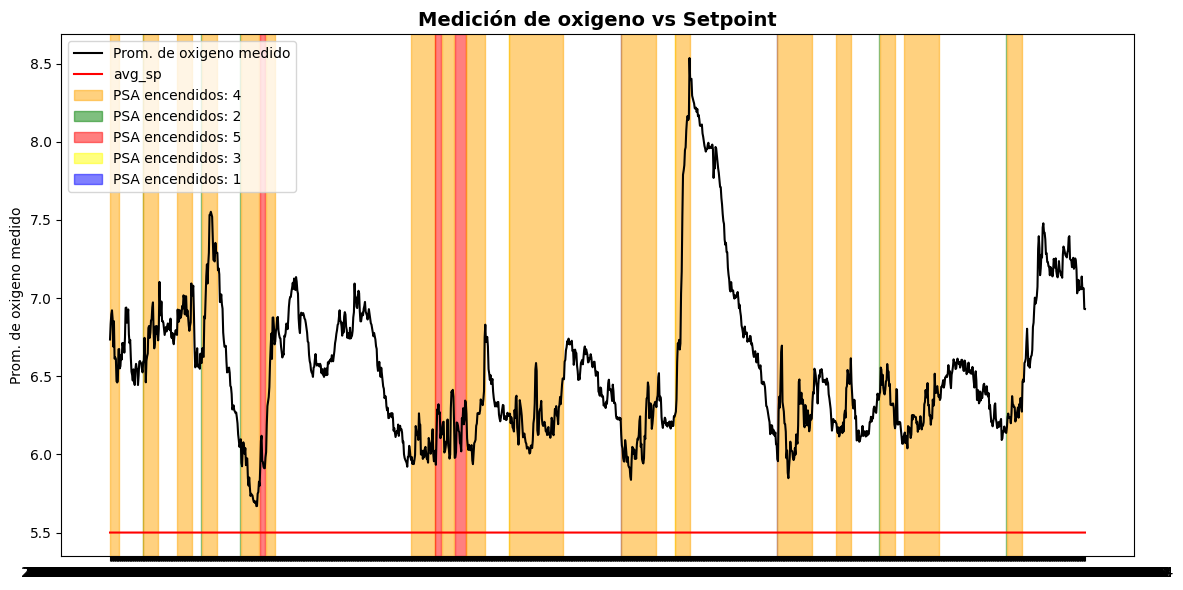

In [12]:
"""El mejor de todos probablemente"""

df = sub_dfs_comp3["POX46"].head(2500)

df = df.tail(1500)

graph(df, title="Medición de oxigeno vs Setpoint")